In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.table import Table
from astropy.timeseries import LombScargle

In [2]:
#---------------------------------------------------------- Data Upload
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------

VVV_data = fits.open('VVV_Sample.fits')

Id_b278, Id_b279 = VVV_data[1].data,VVV_data[11].data

Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data

#---------------------------------------------------------- Removing np.nan 
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------
#-----------------------------------------------------------------------------

# Remove missing values (NaNs) from all Ks-related data arrays

def remove_nans(array2d):
    return [row[~np.isnan(row)] for row in array2d]

def _safe_norm(x):
    xmin, xmax = np.min(x), np.max(x)
    return (x - xmin) / (xmax - xmin)

Ks_b278 = remove_nans(Ks_b278) #Magnitudes
Ks_b279 = remove_nans(Ks_b279)

Ks_err_b278 = remove_nans(Ks_err_b278)  #Errores en magnitudes
Ks_err_b279 = remove_nans(Ks_err_b279)

Ks_mjd_b278 = remove_nans(Ks_mjd_b278) #Fechas de observación
Ks_mjd_b279 = remove_nans(Ks_mjd_b279)

In [3]:
VVV_data.info()

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [4]:
def phase_folding(periodo, mjd):
    phase = ((mjd - mjd[0]) % periodo) / periodo
    return phase

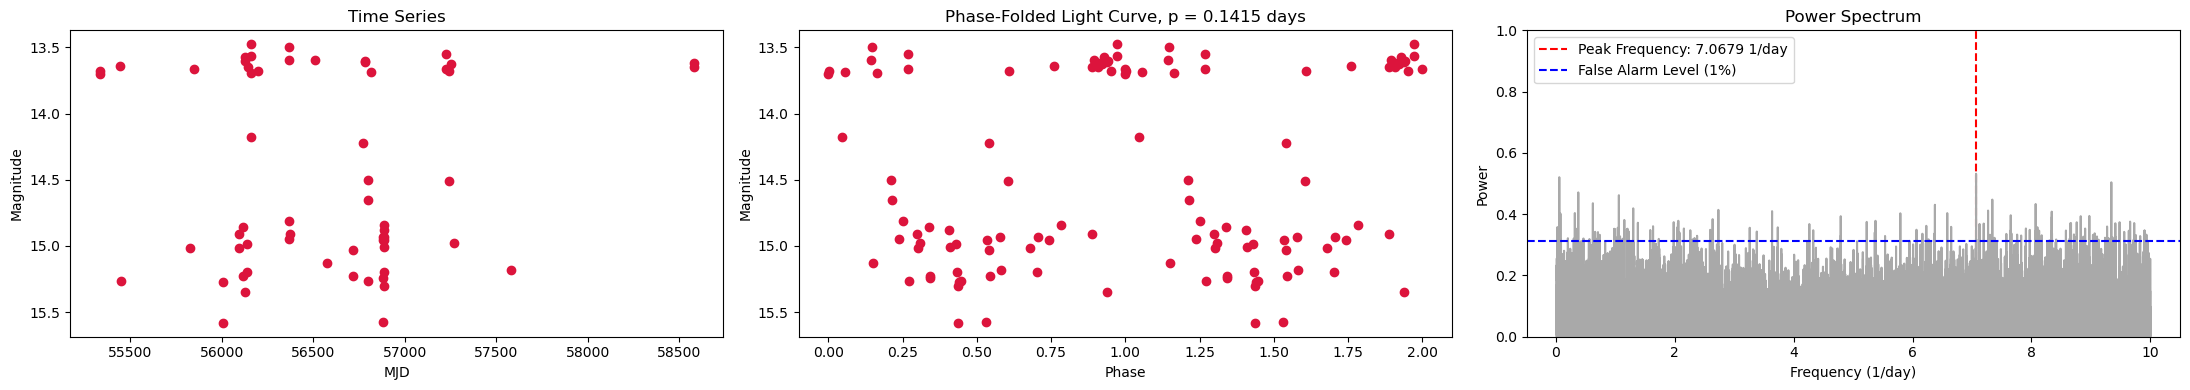

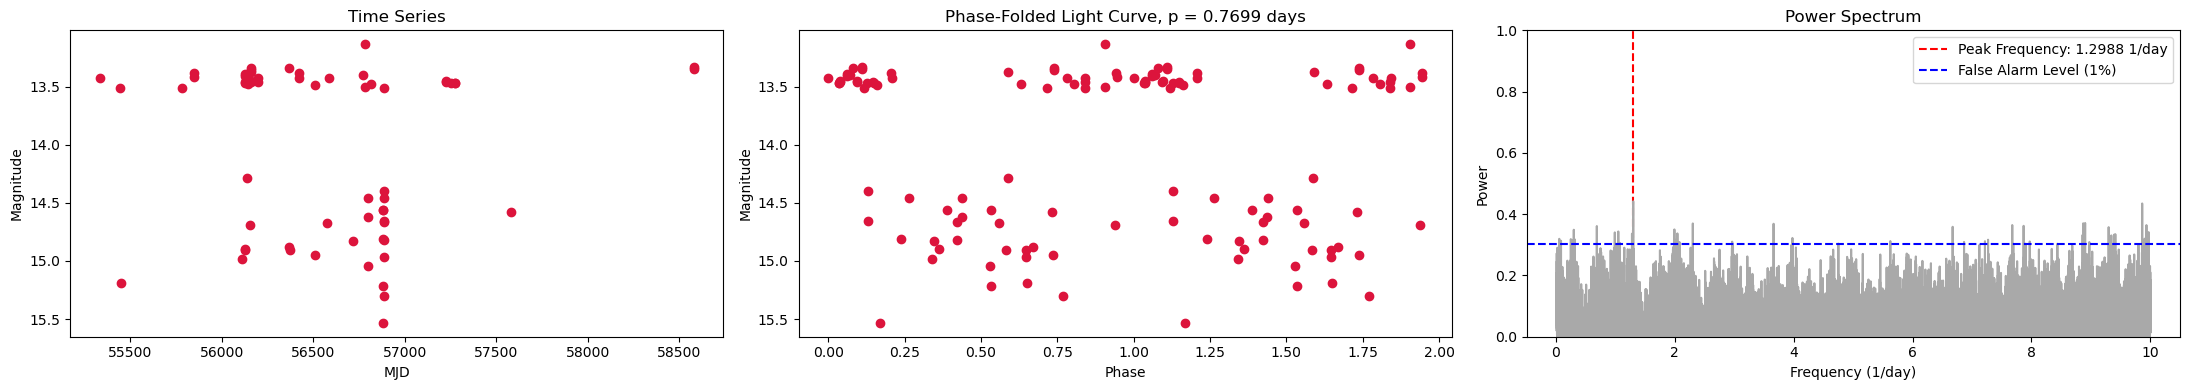

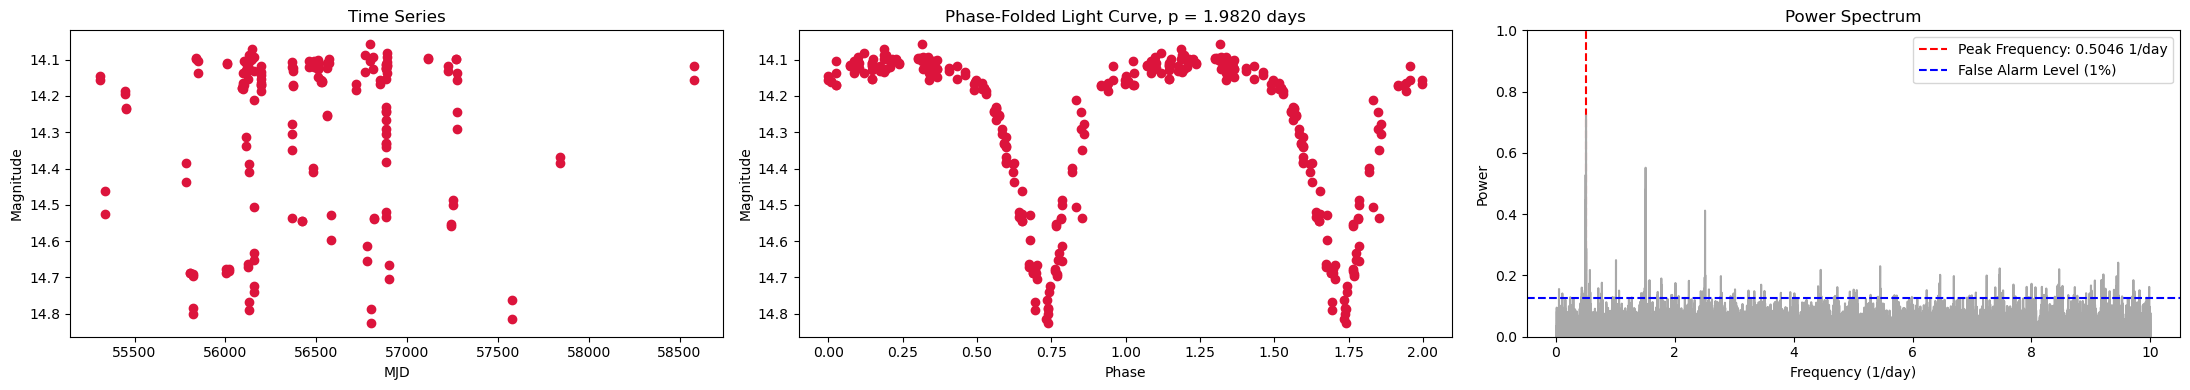

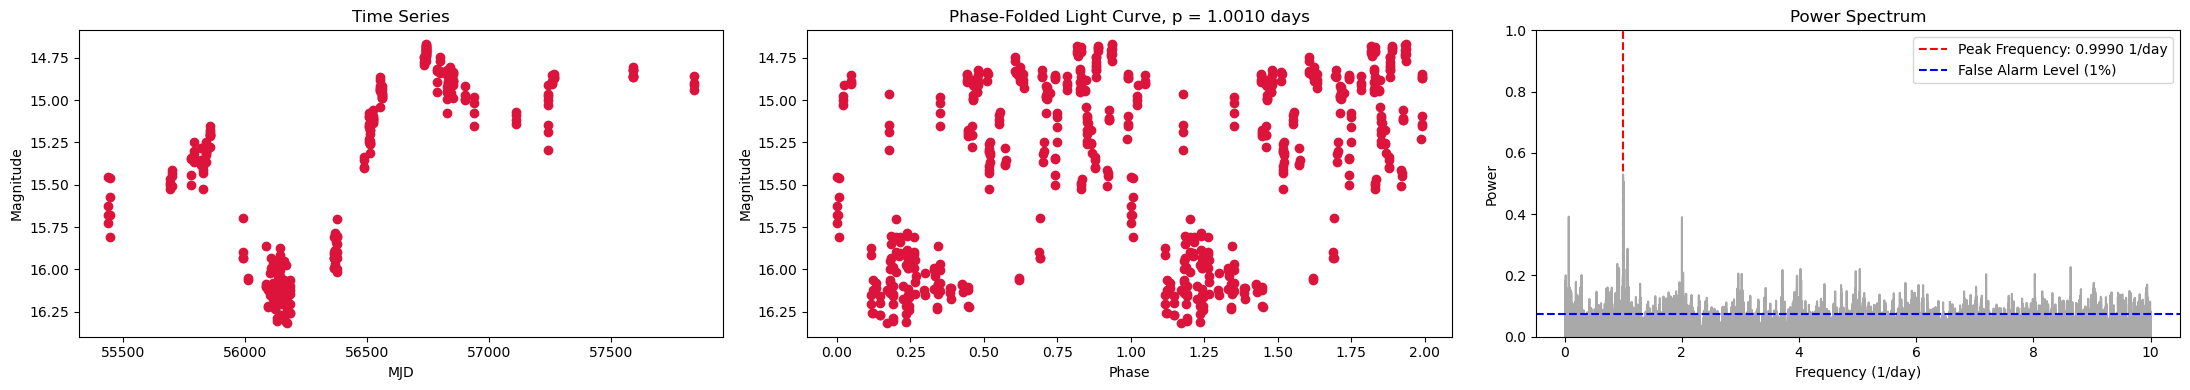

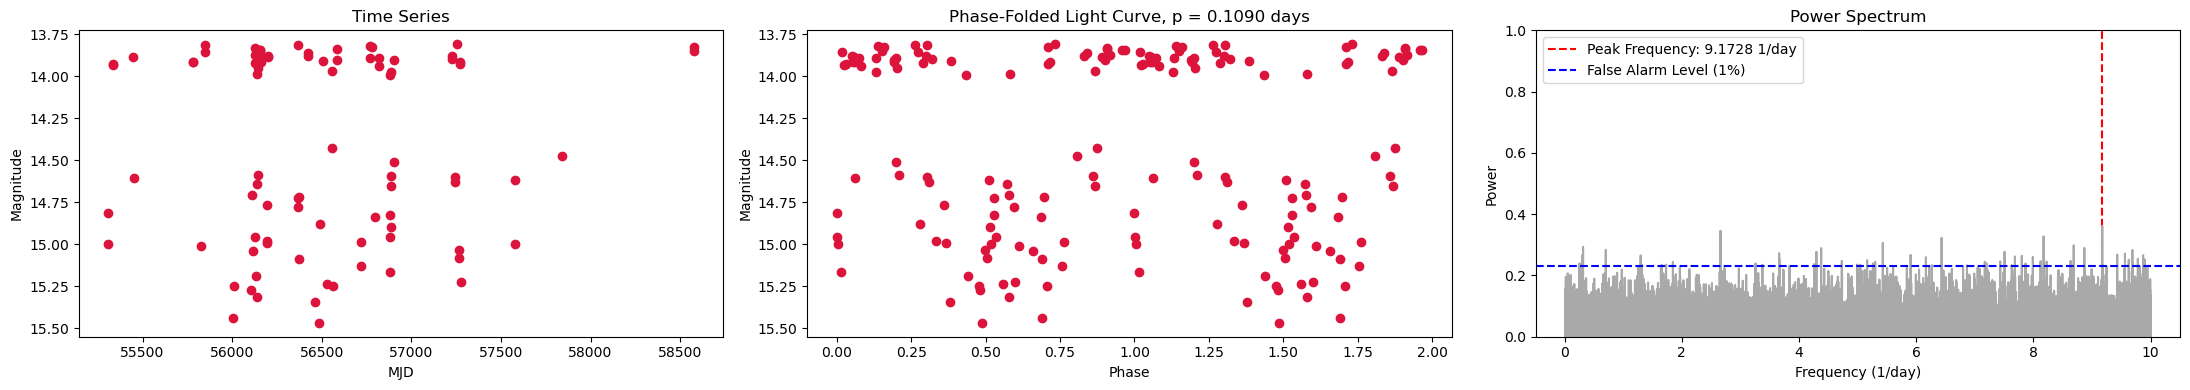

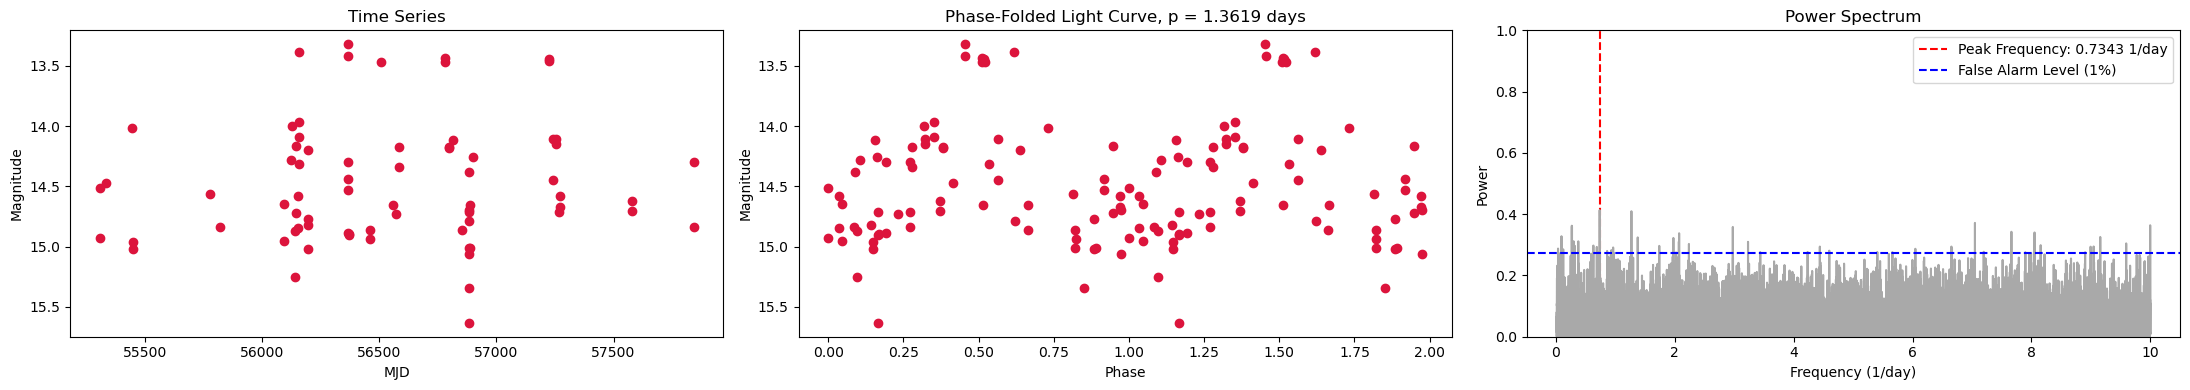

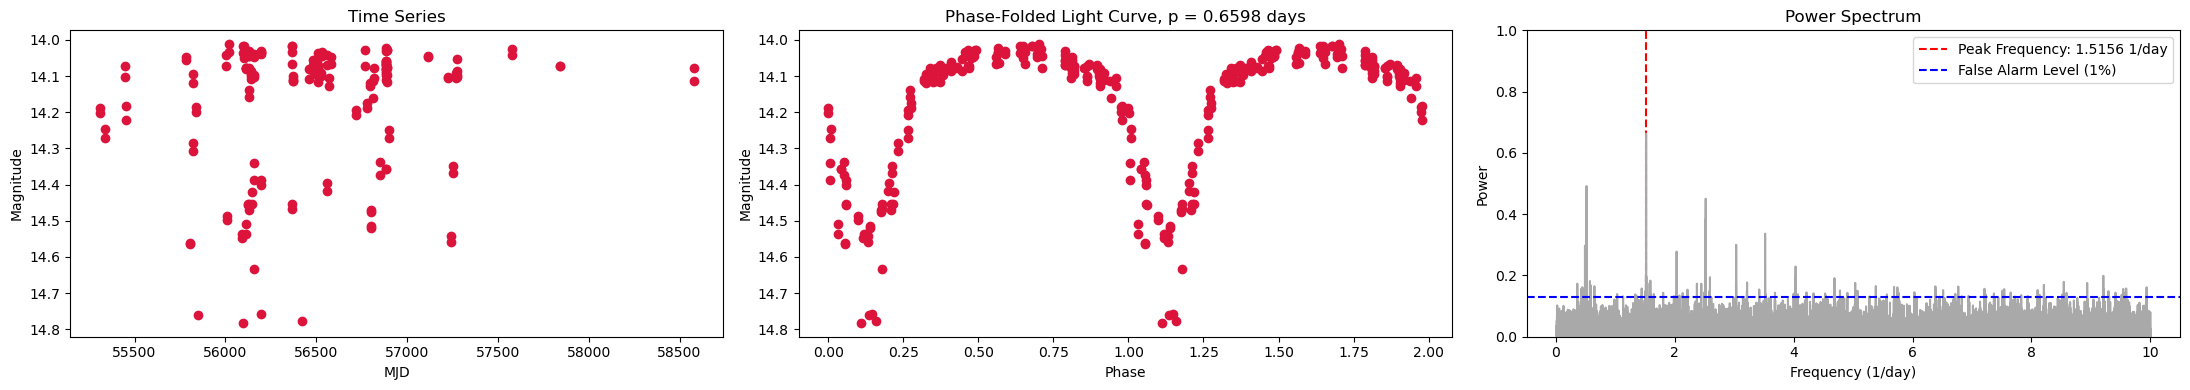

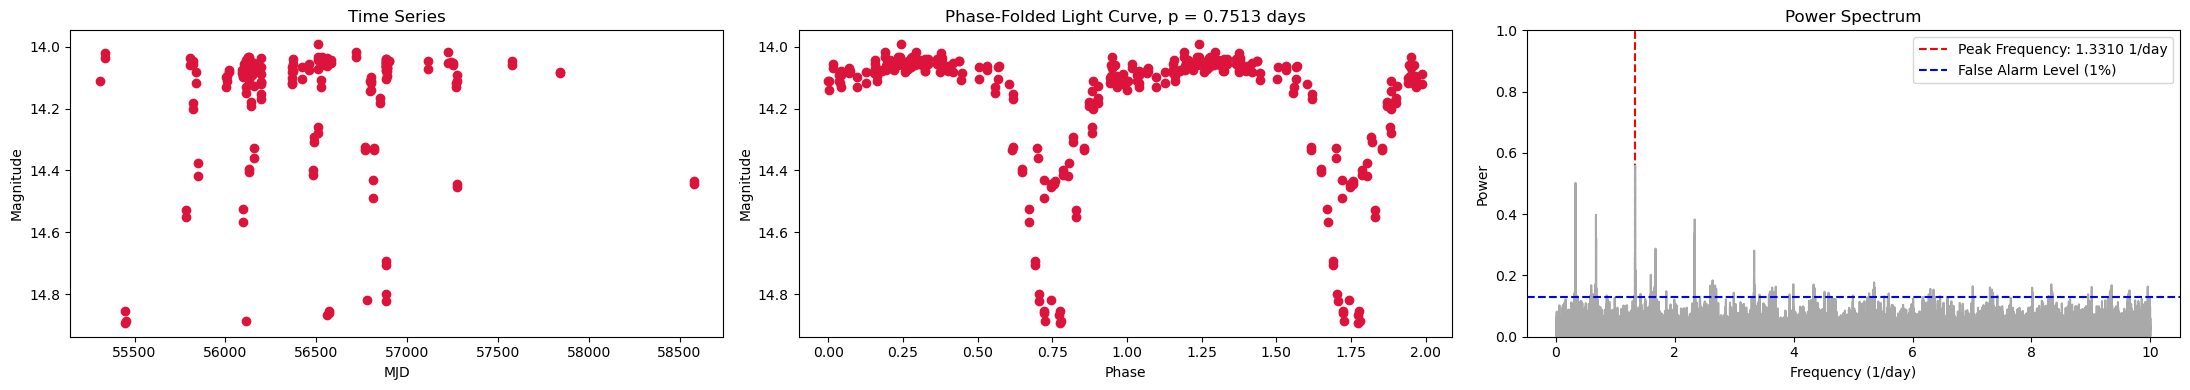

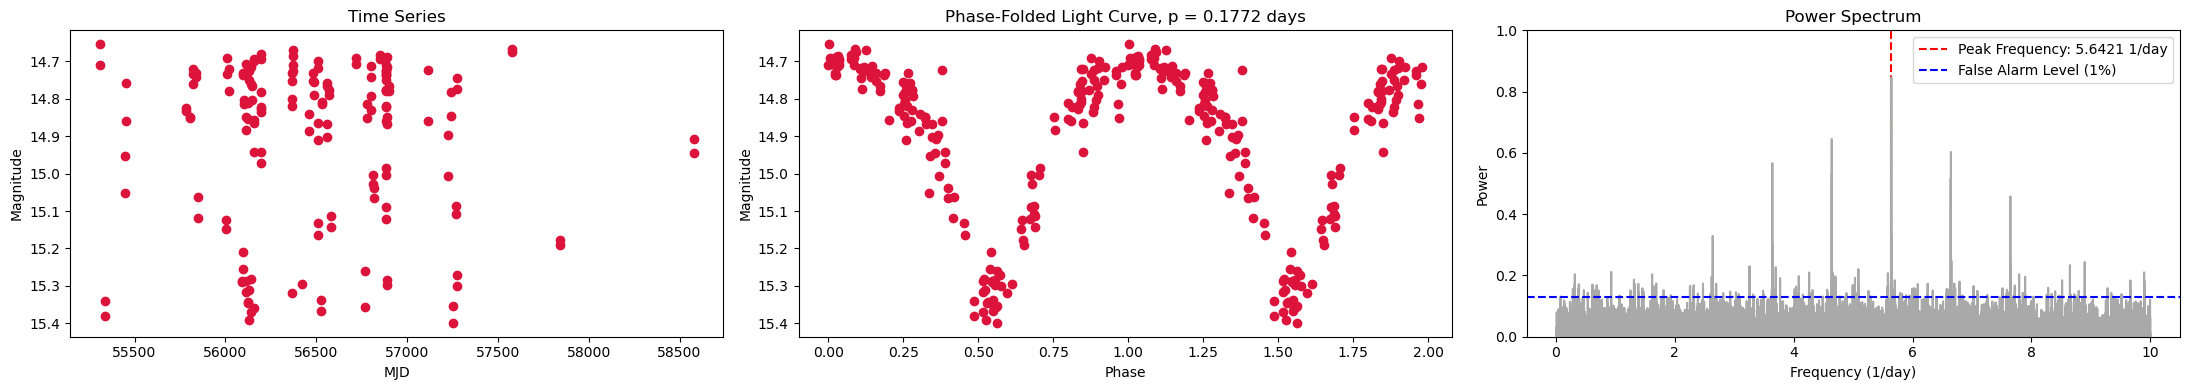

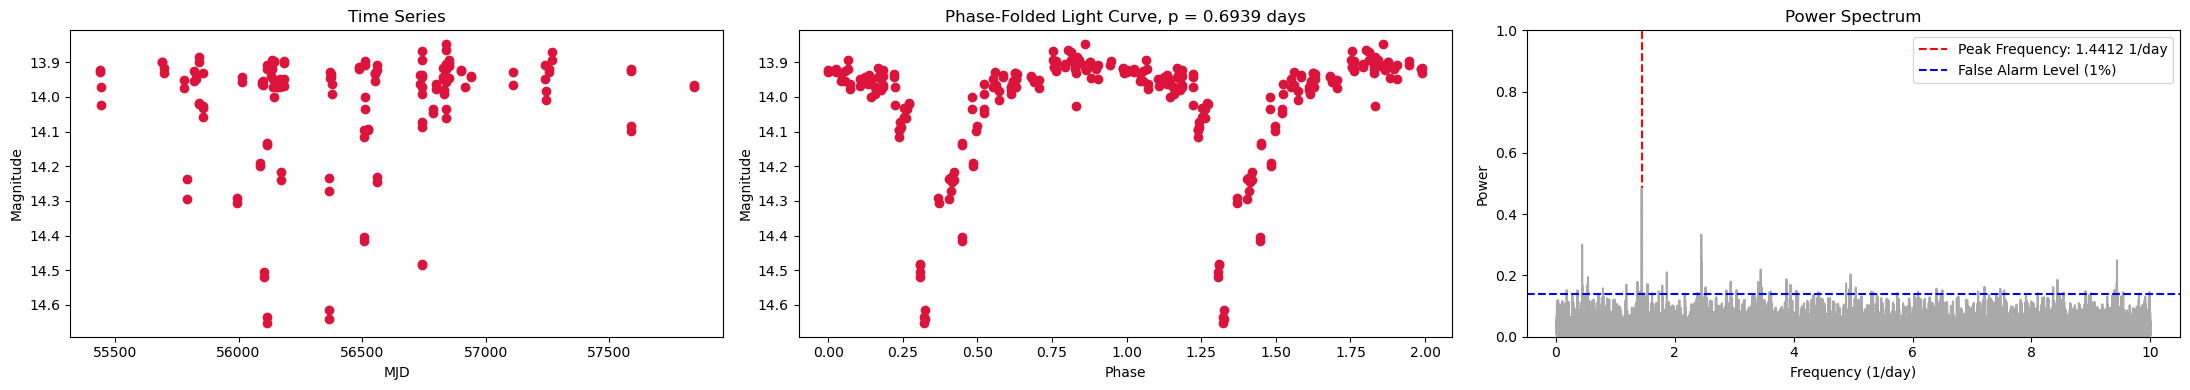

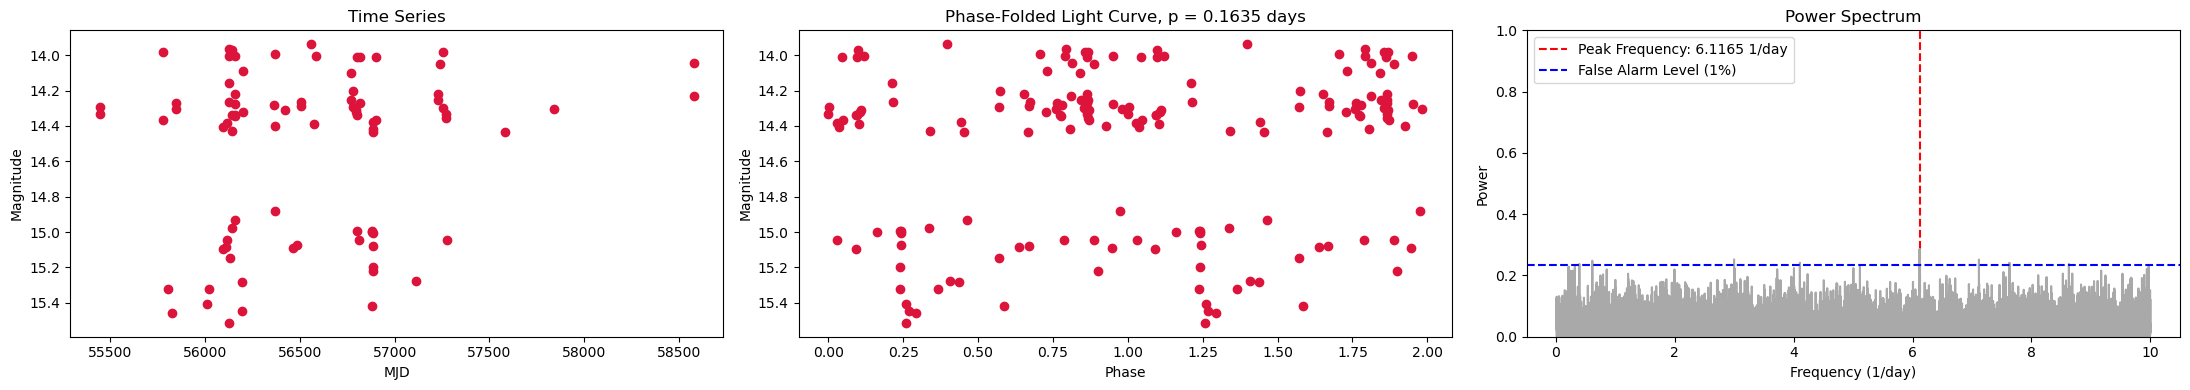

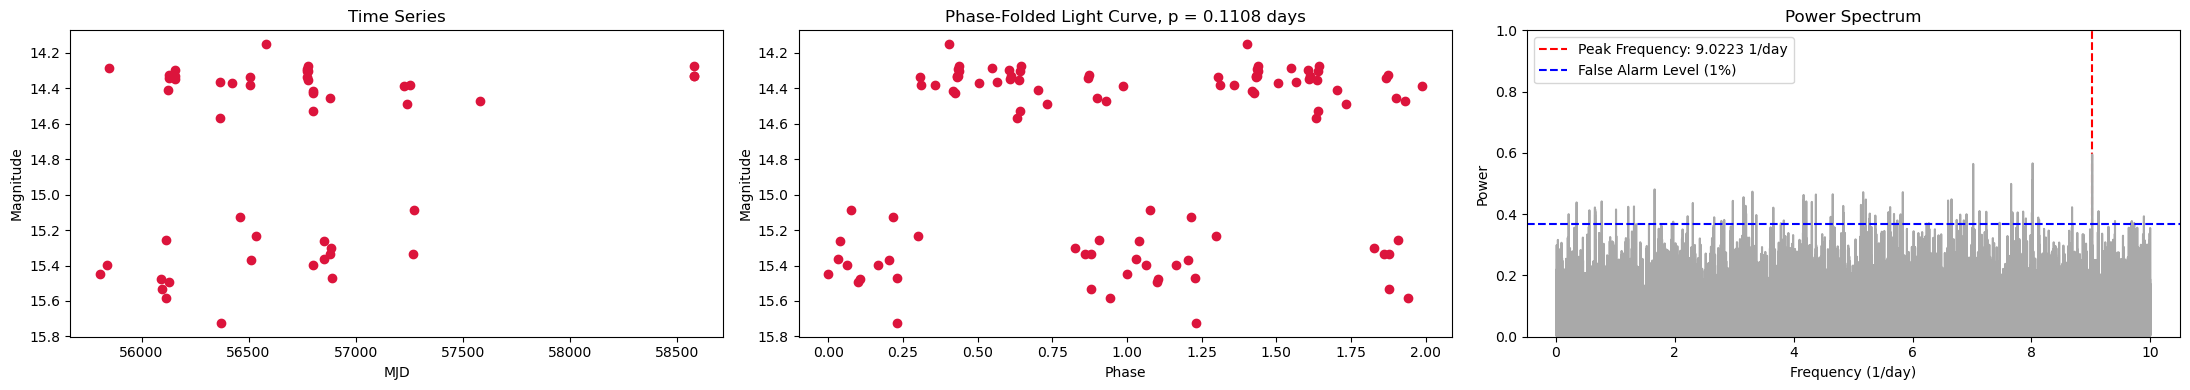

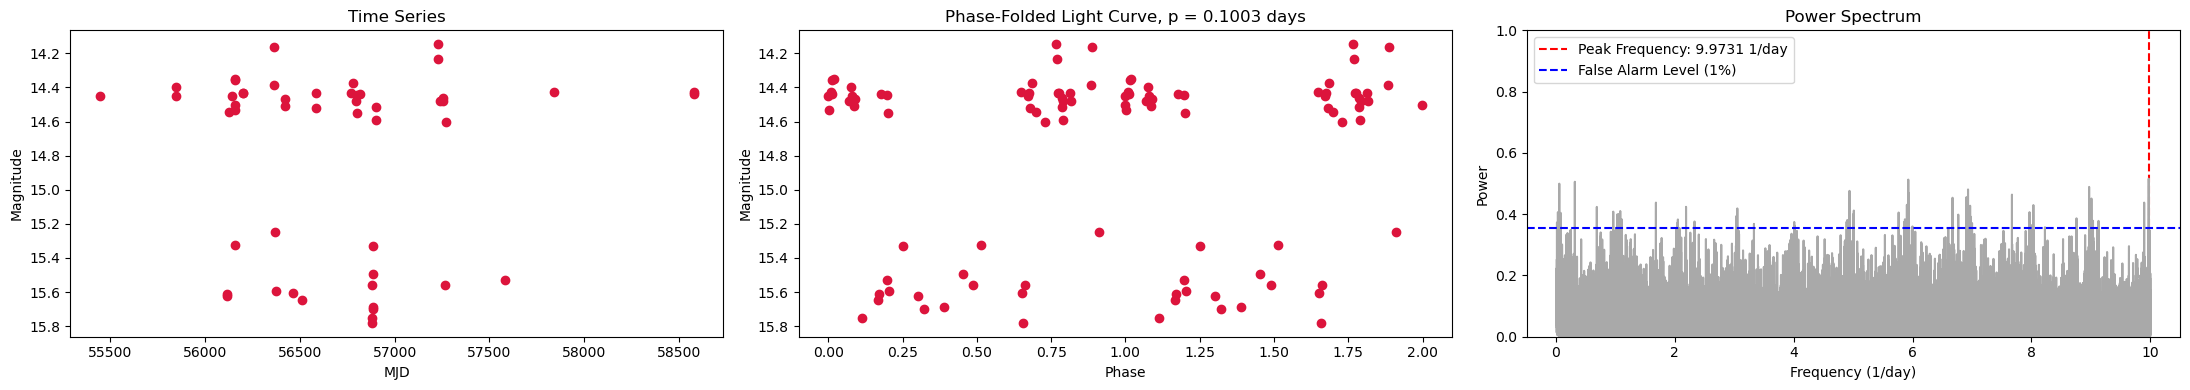

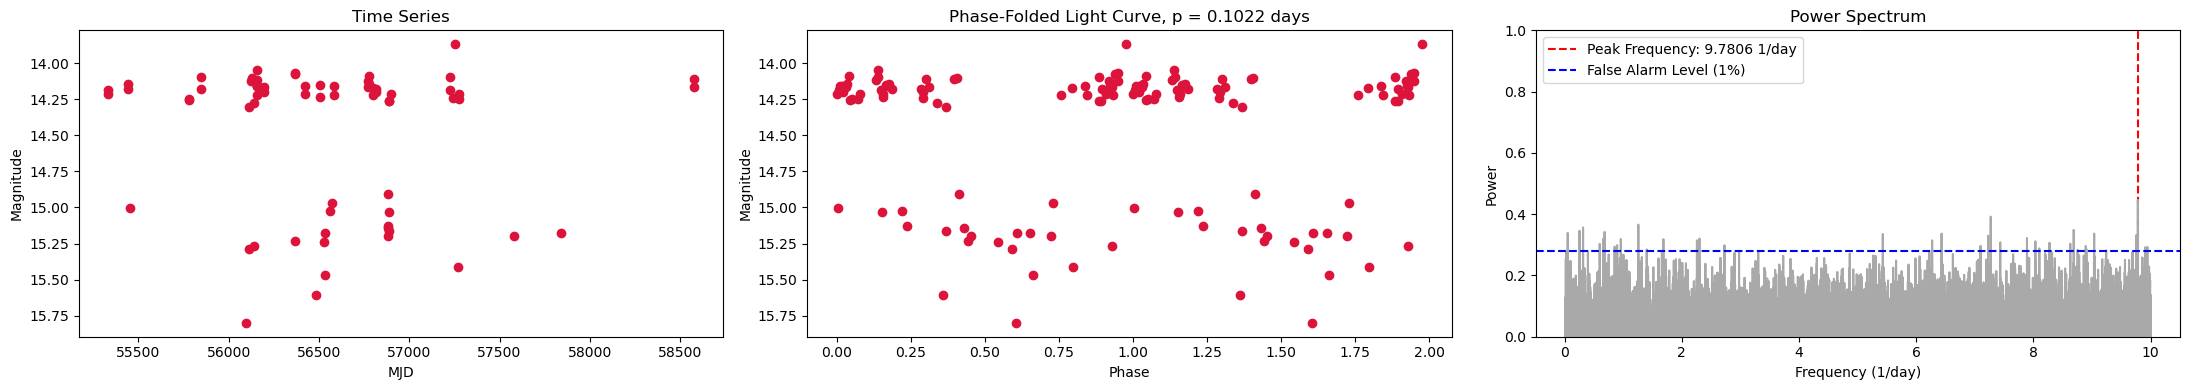

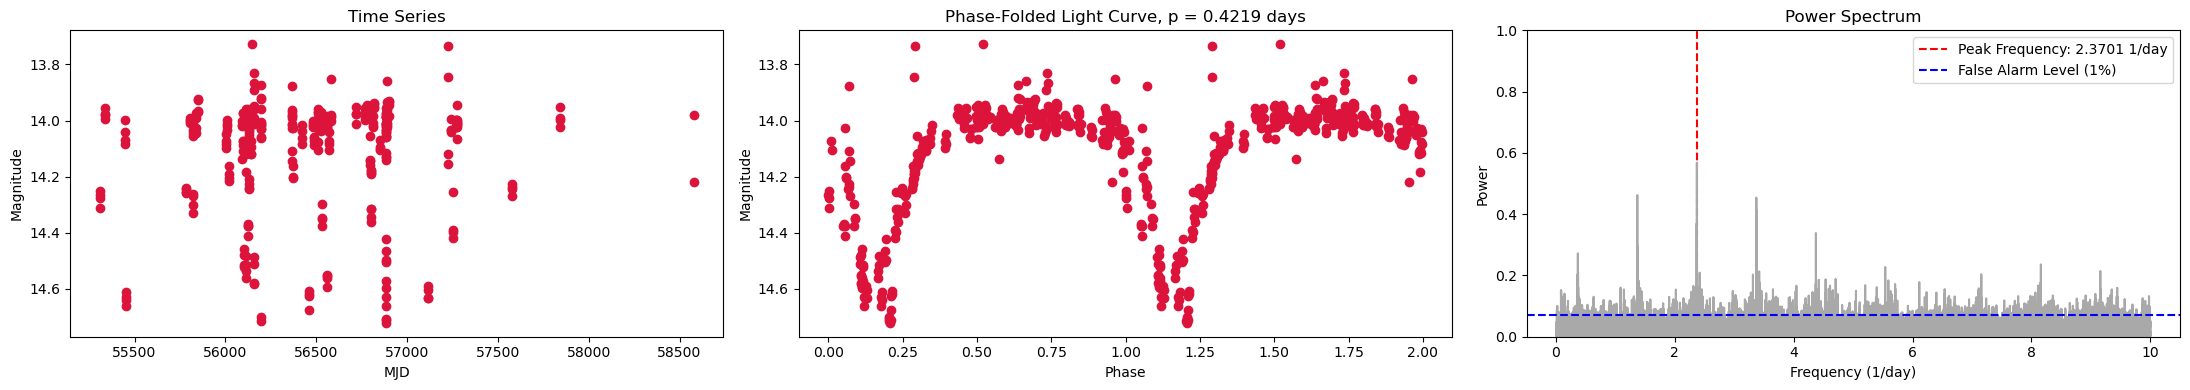

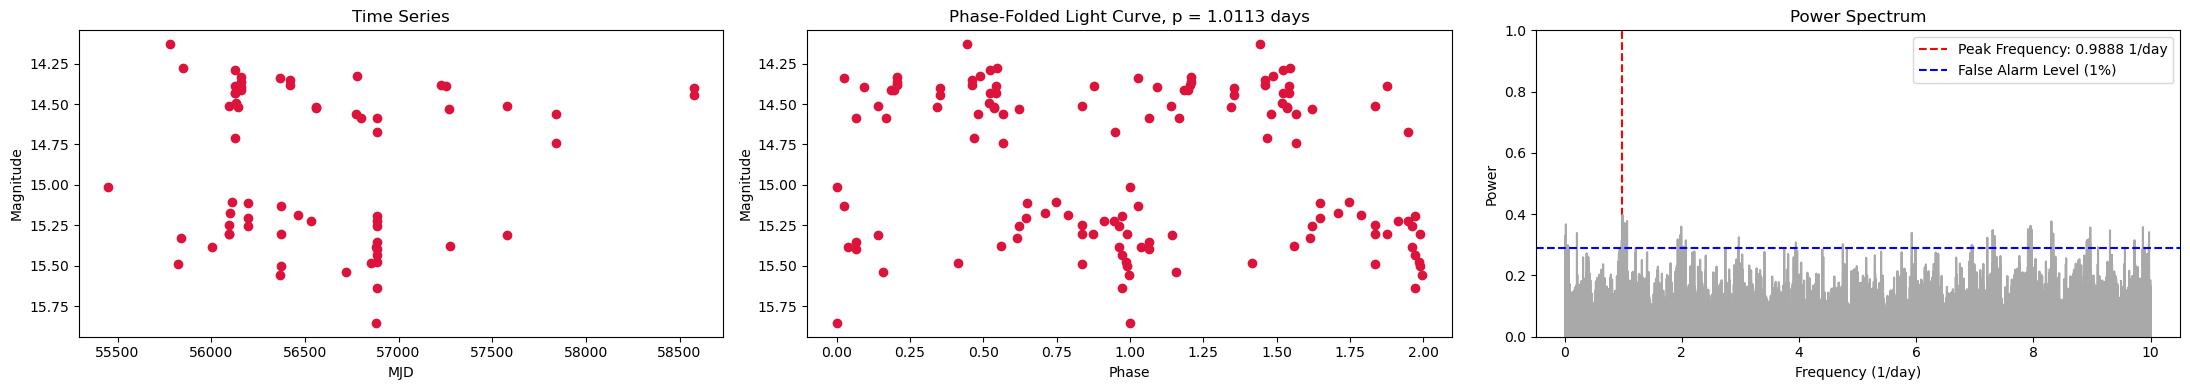

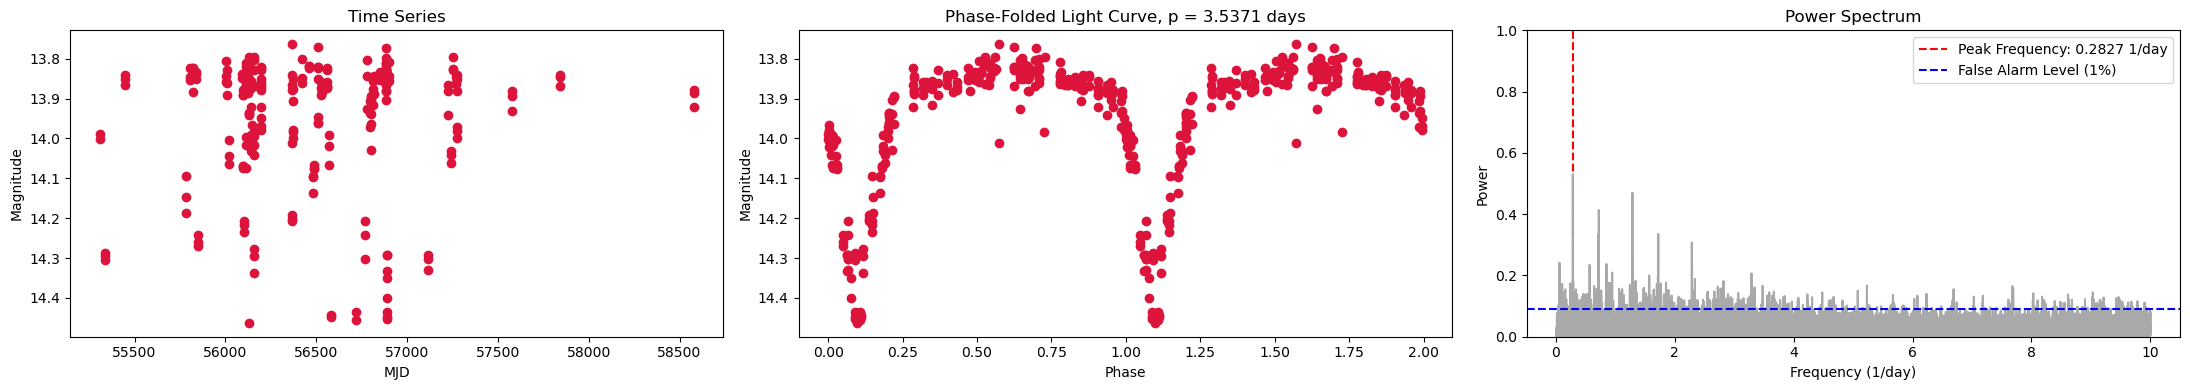

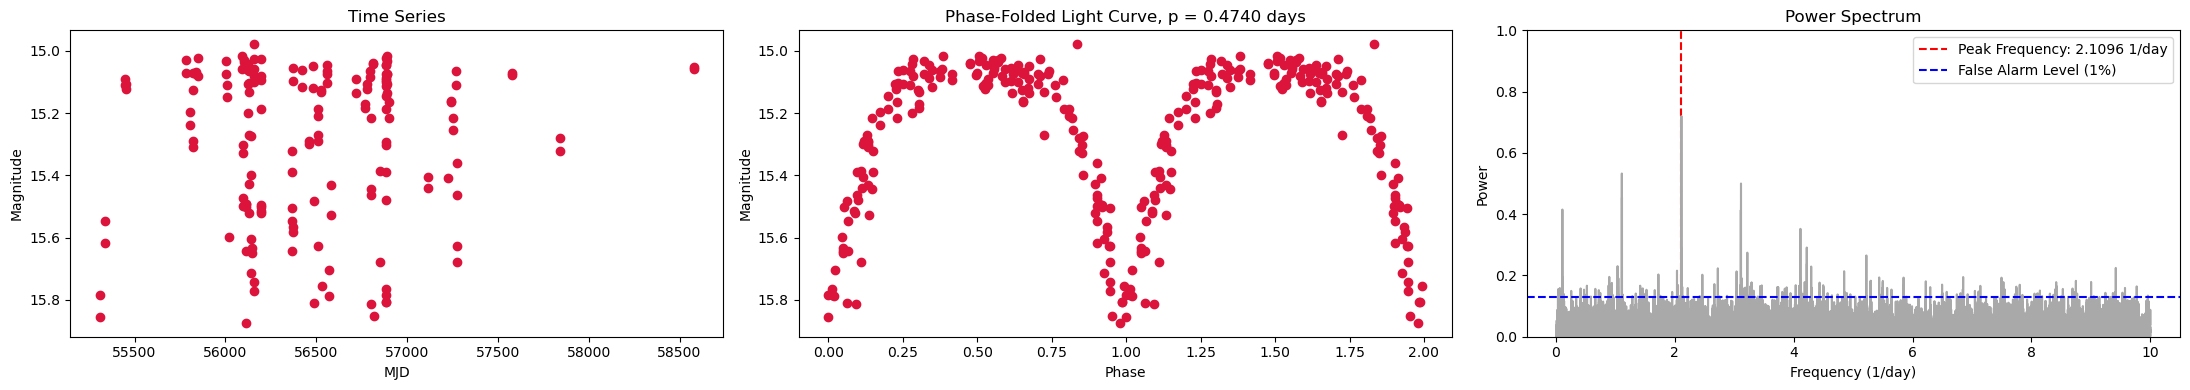

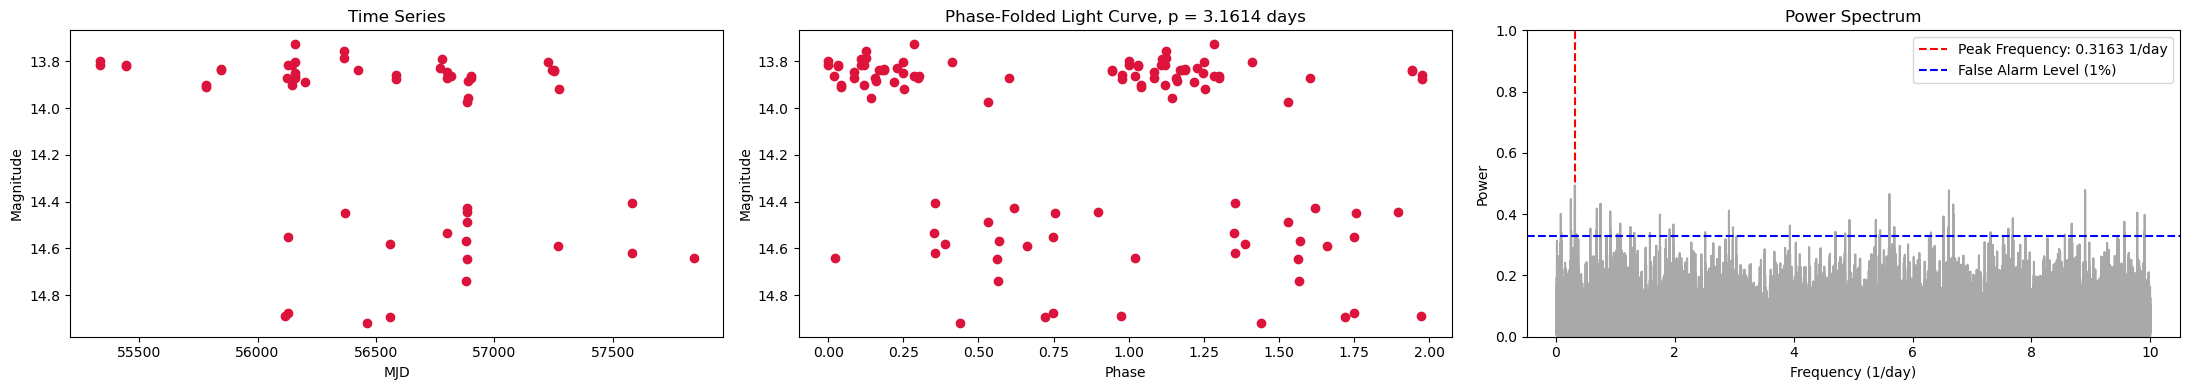

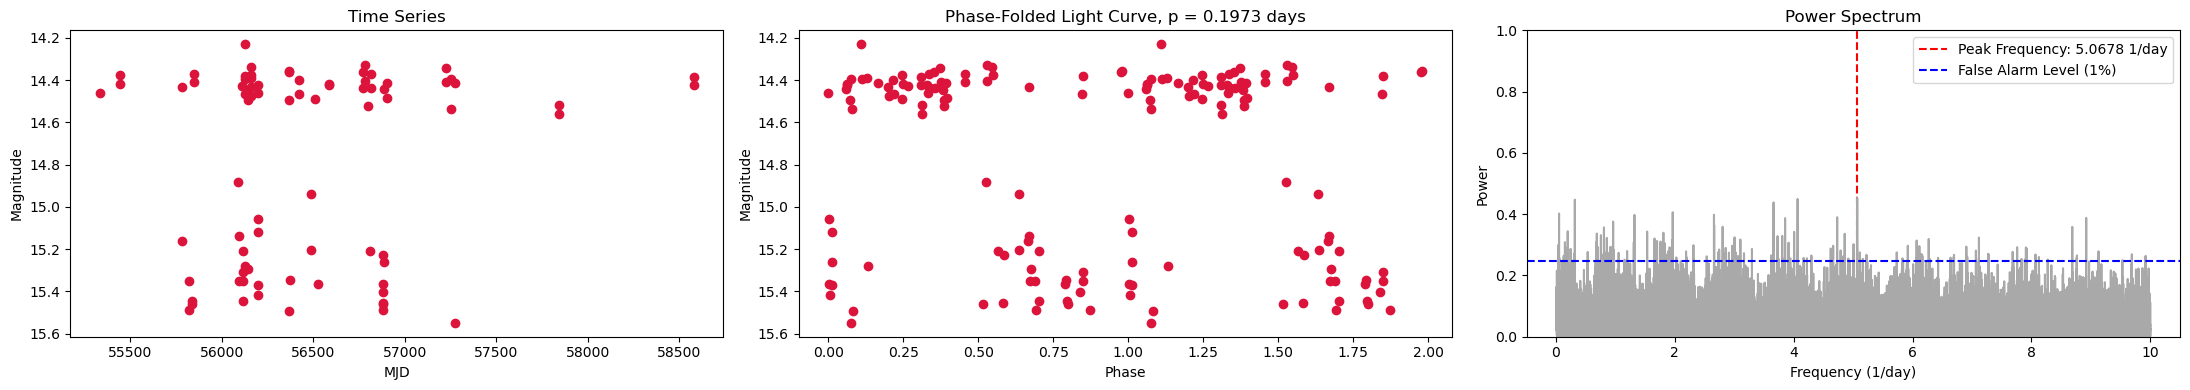

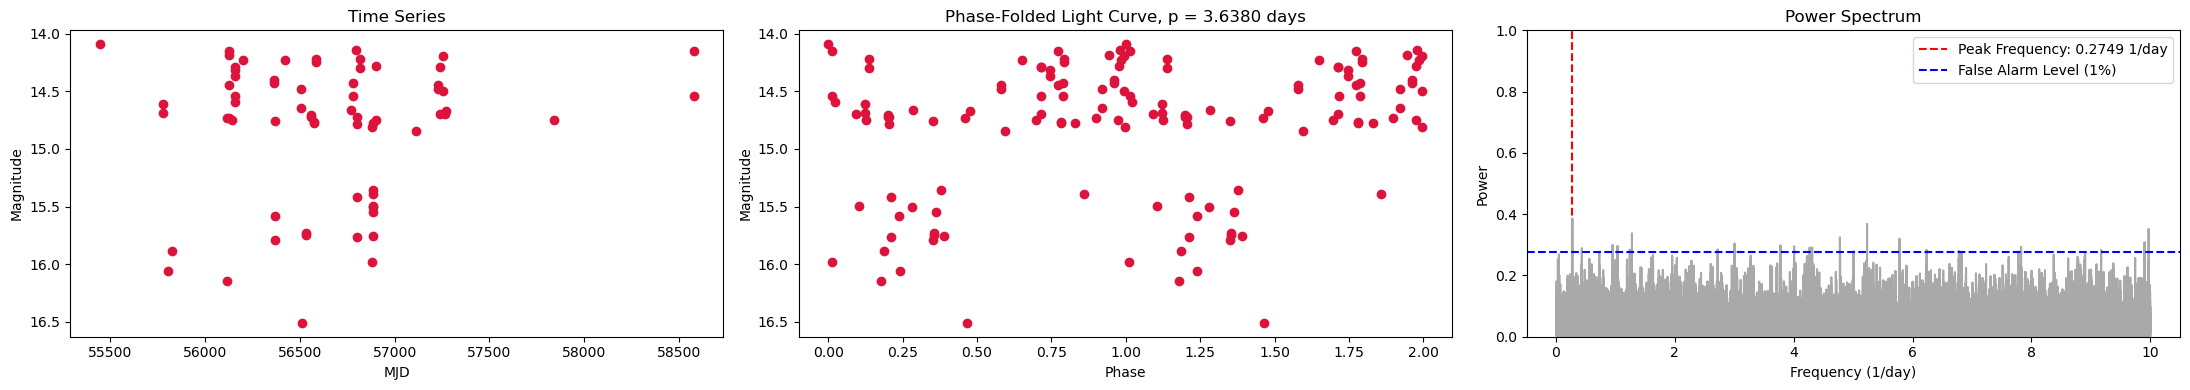

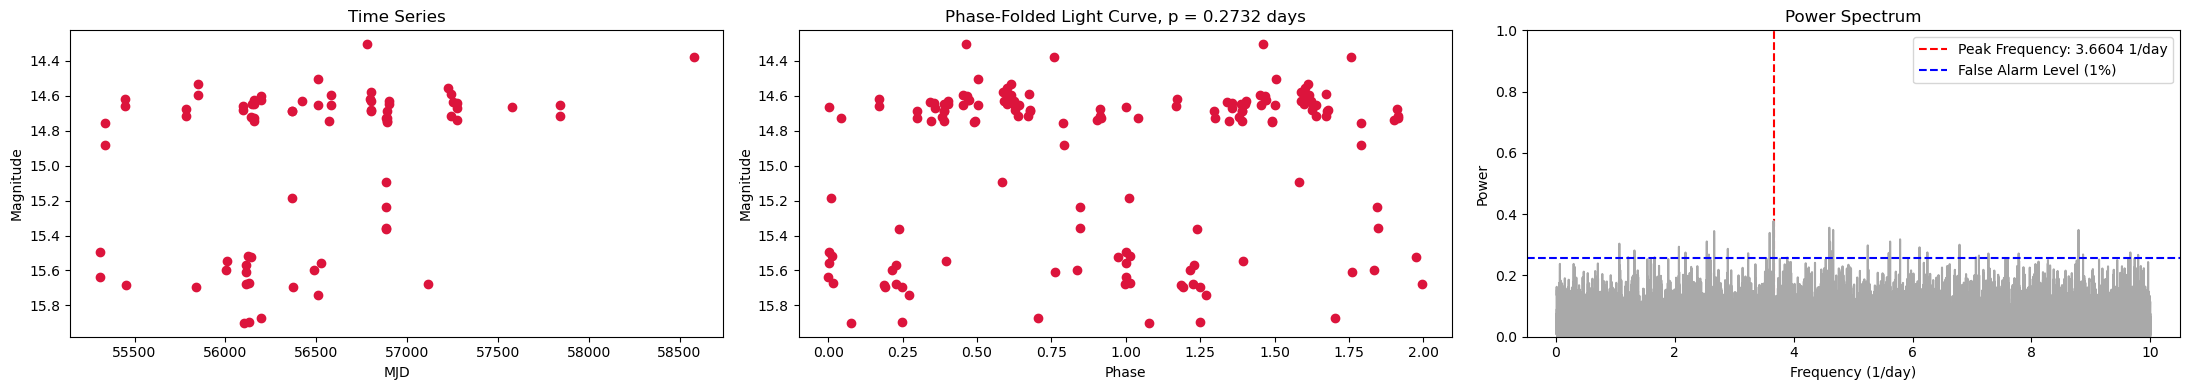

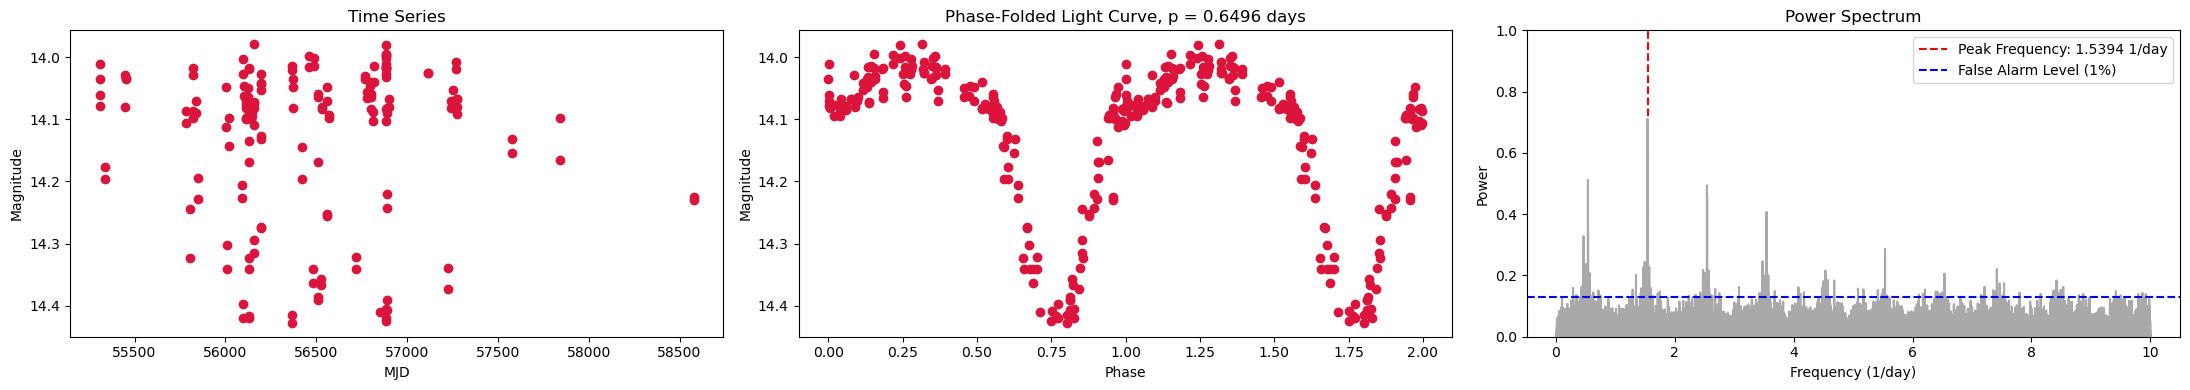

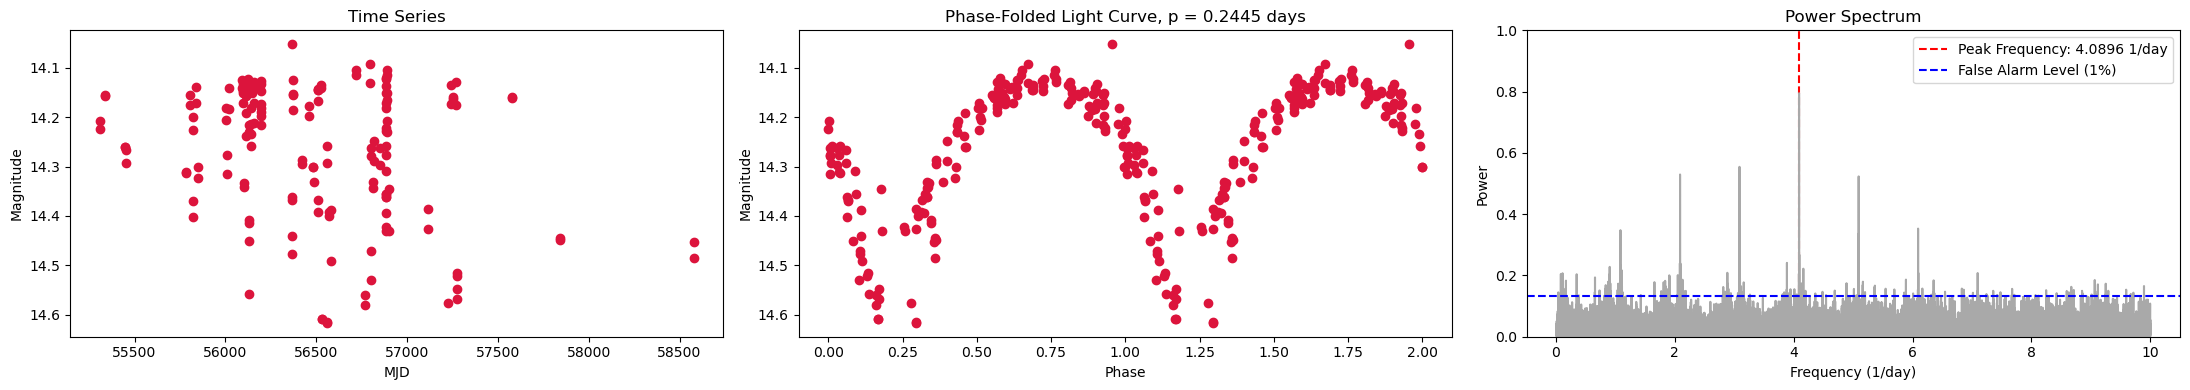

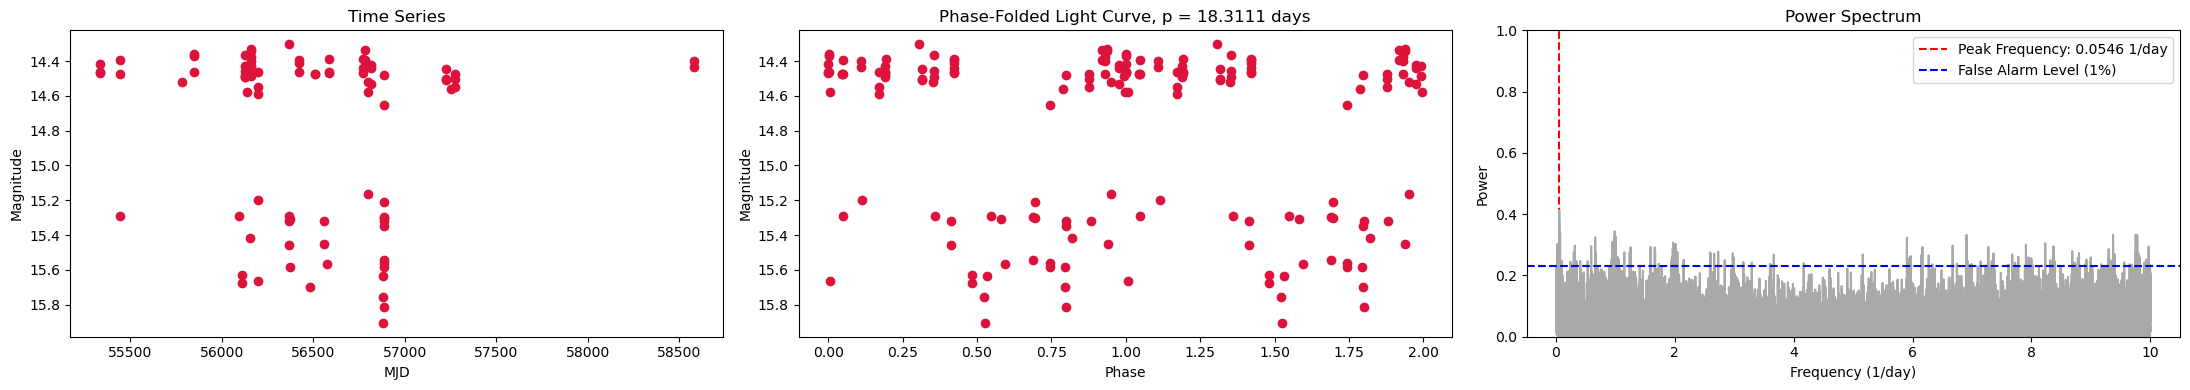

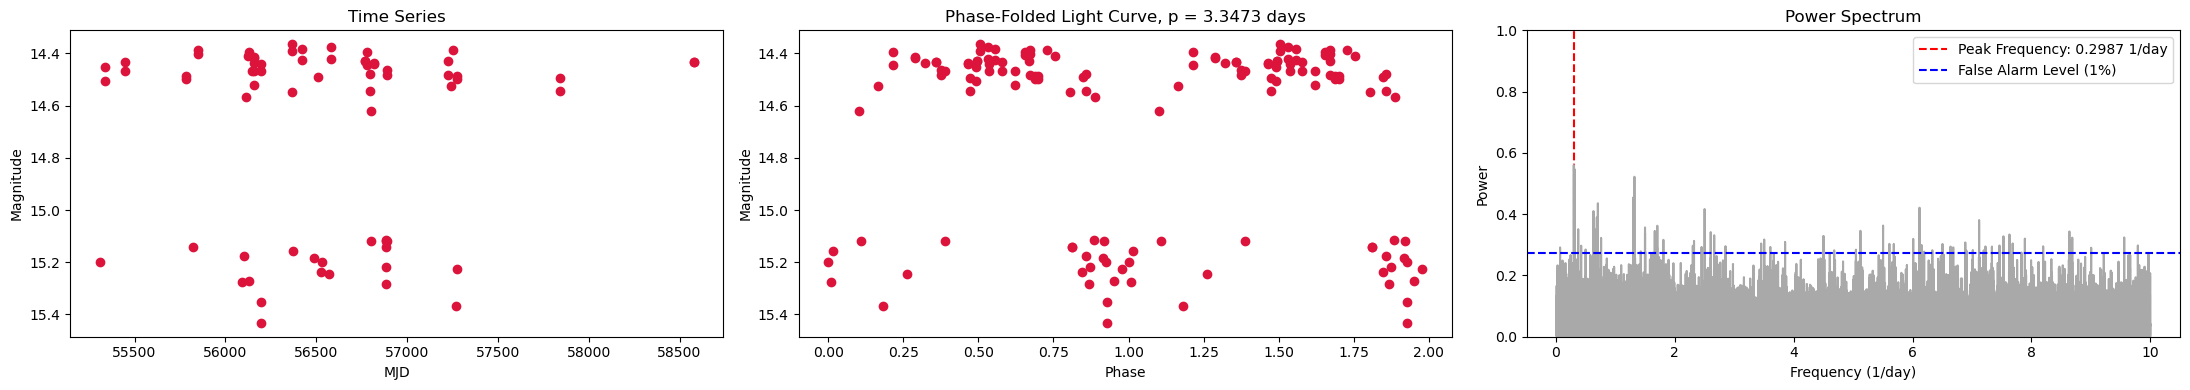

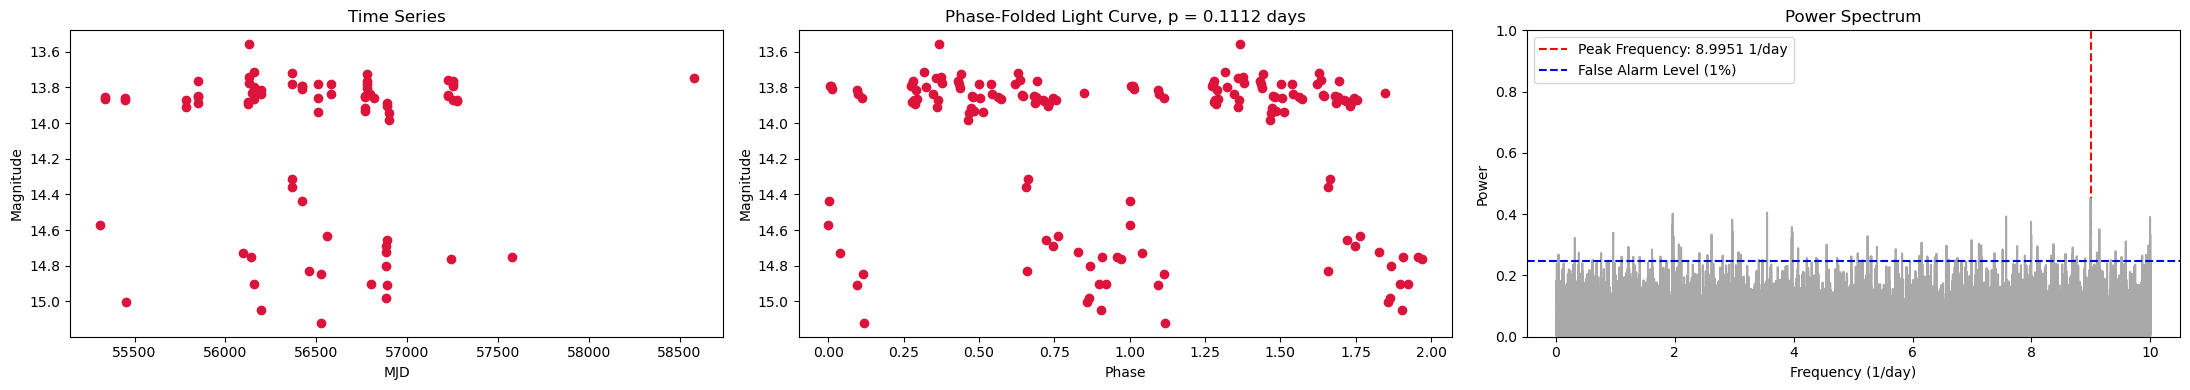

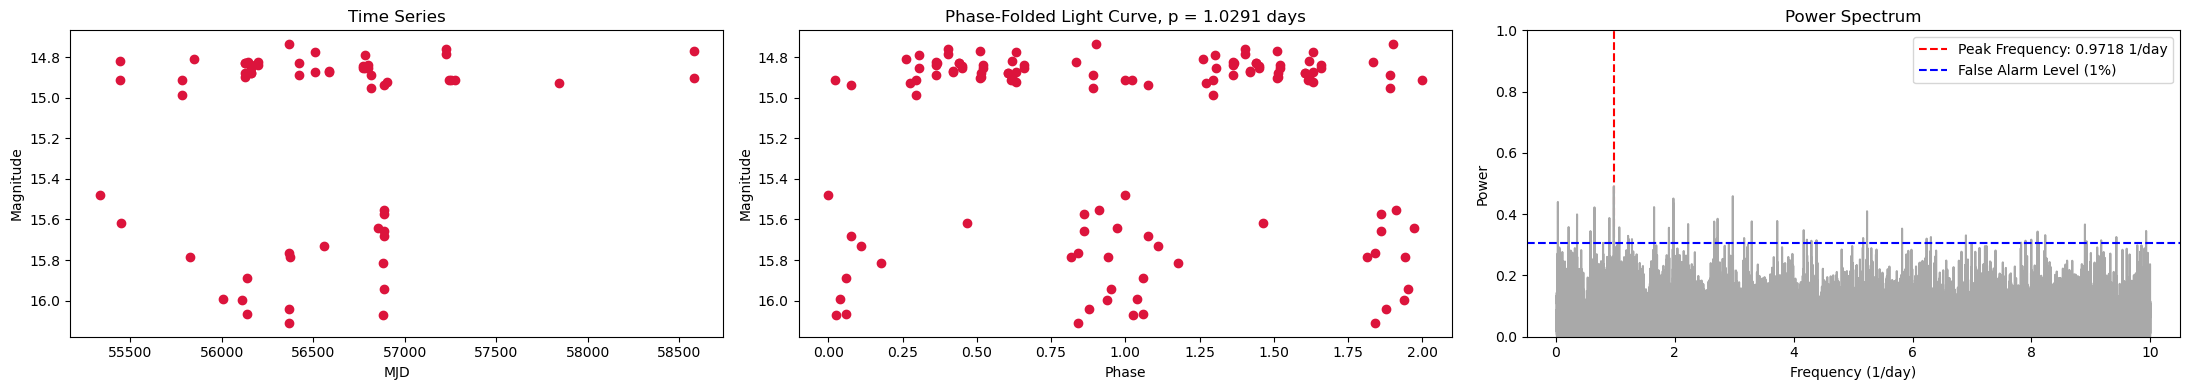

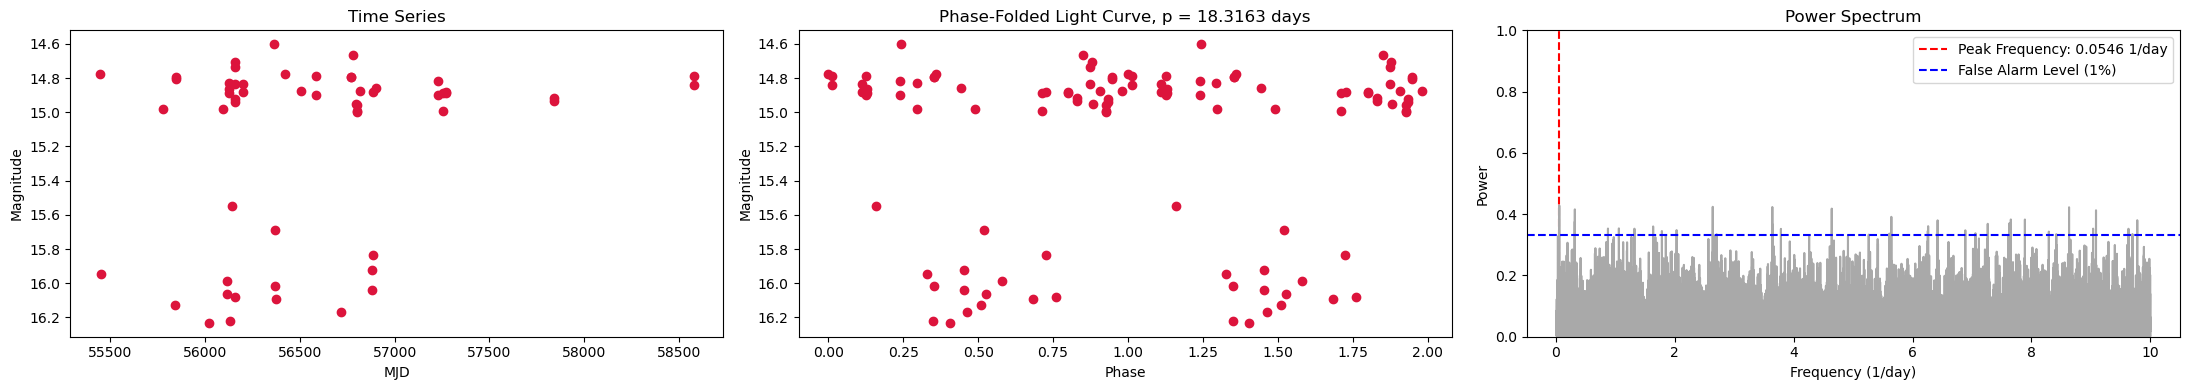

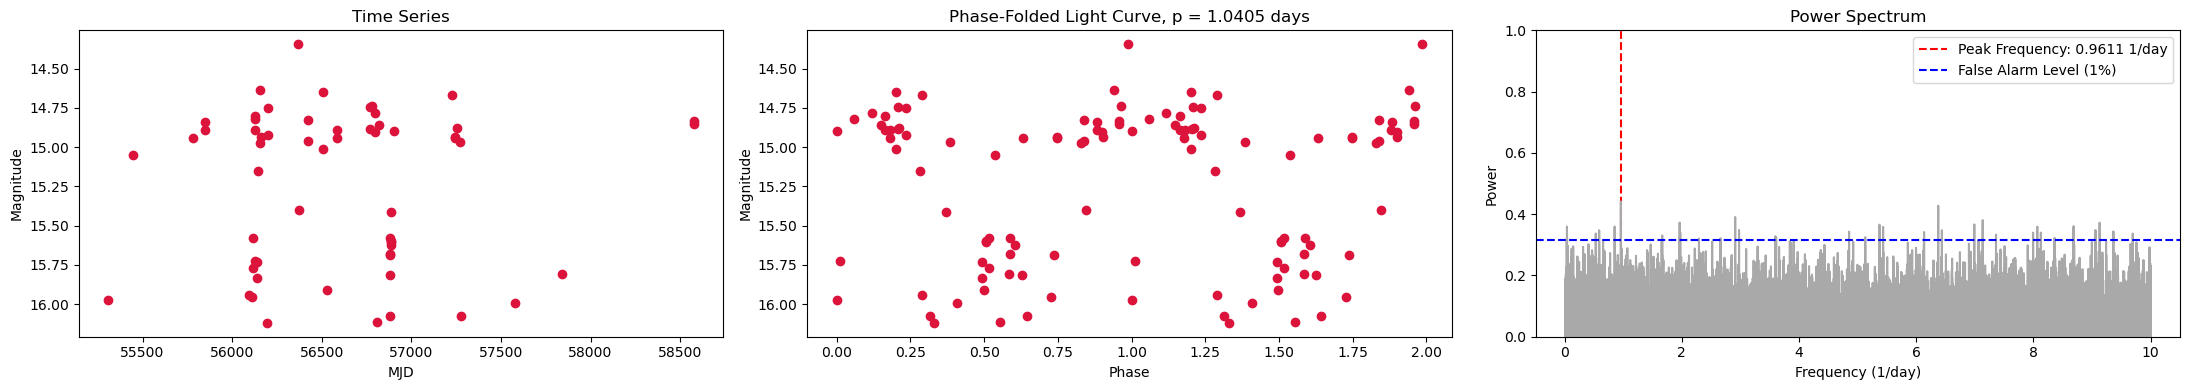

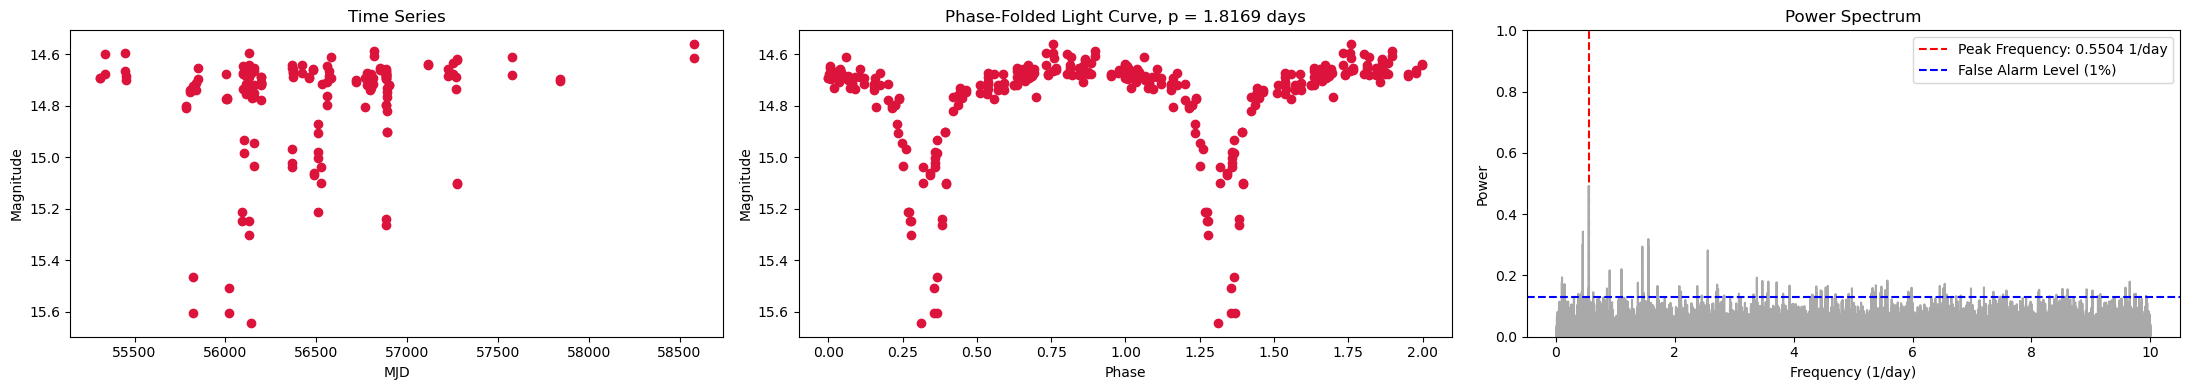

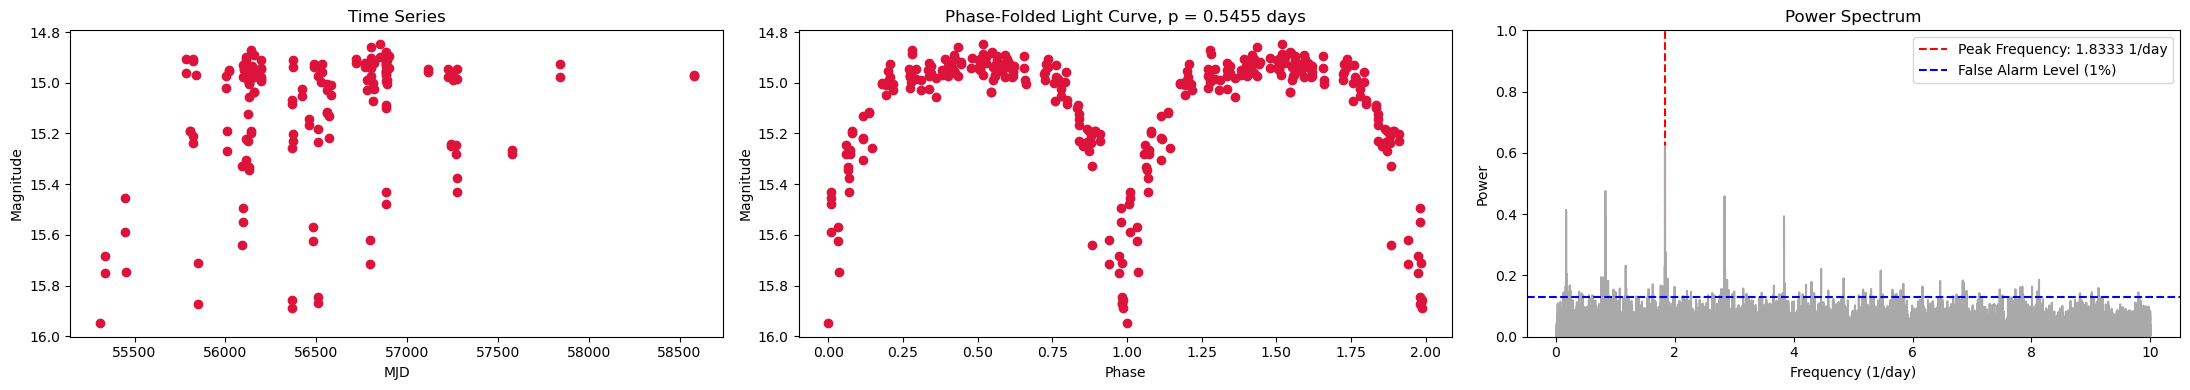

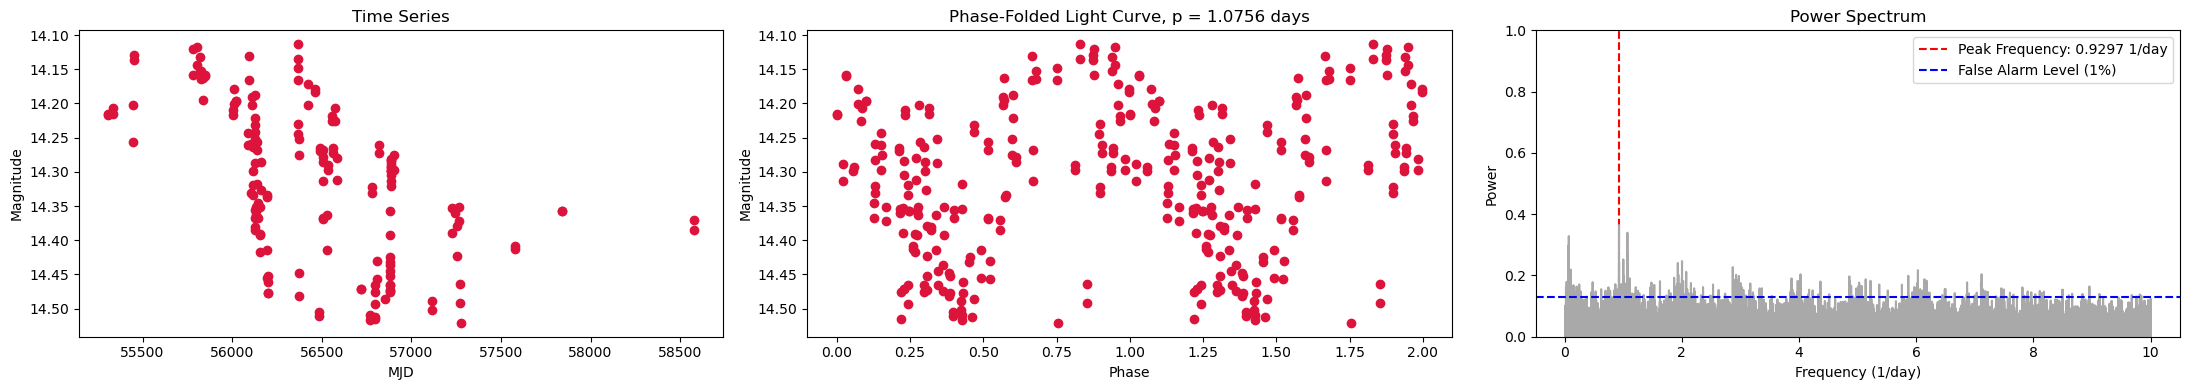

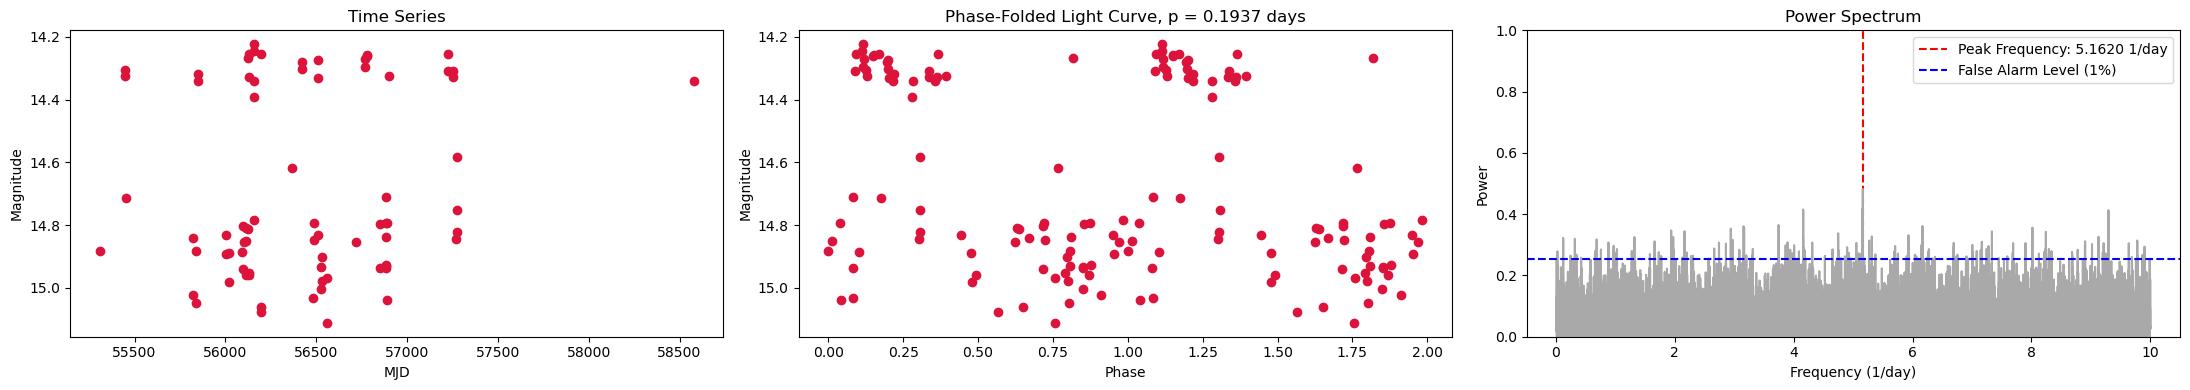

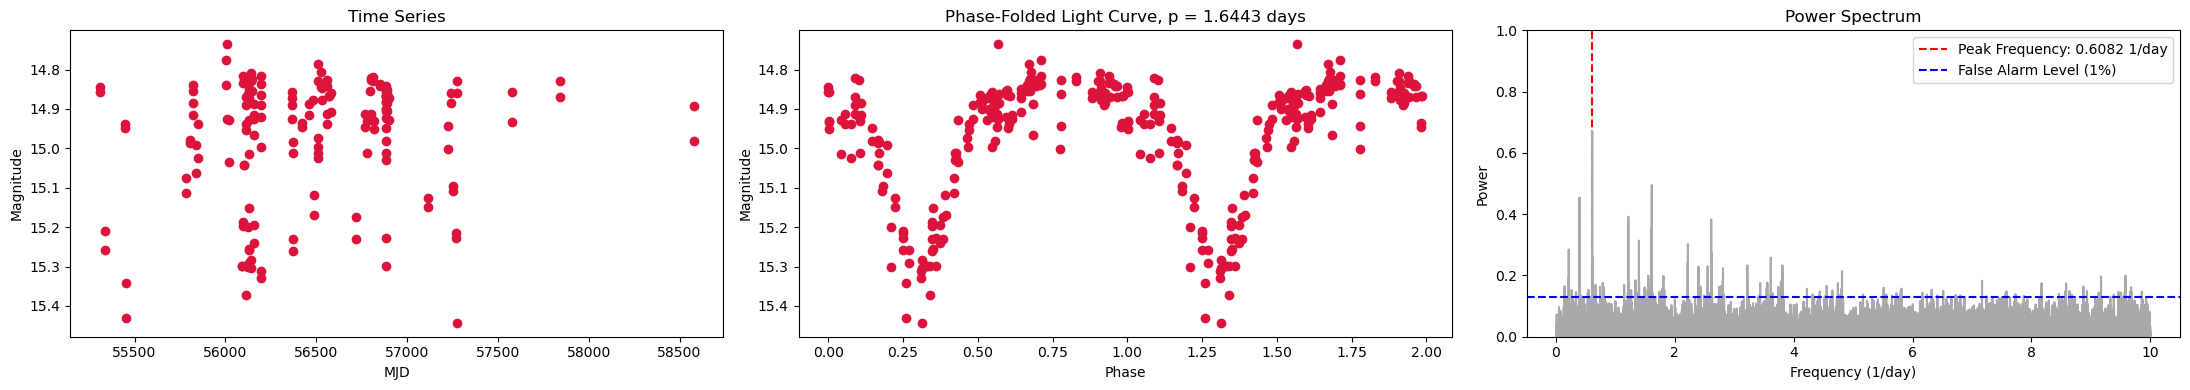

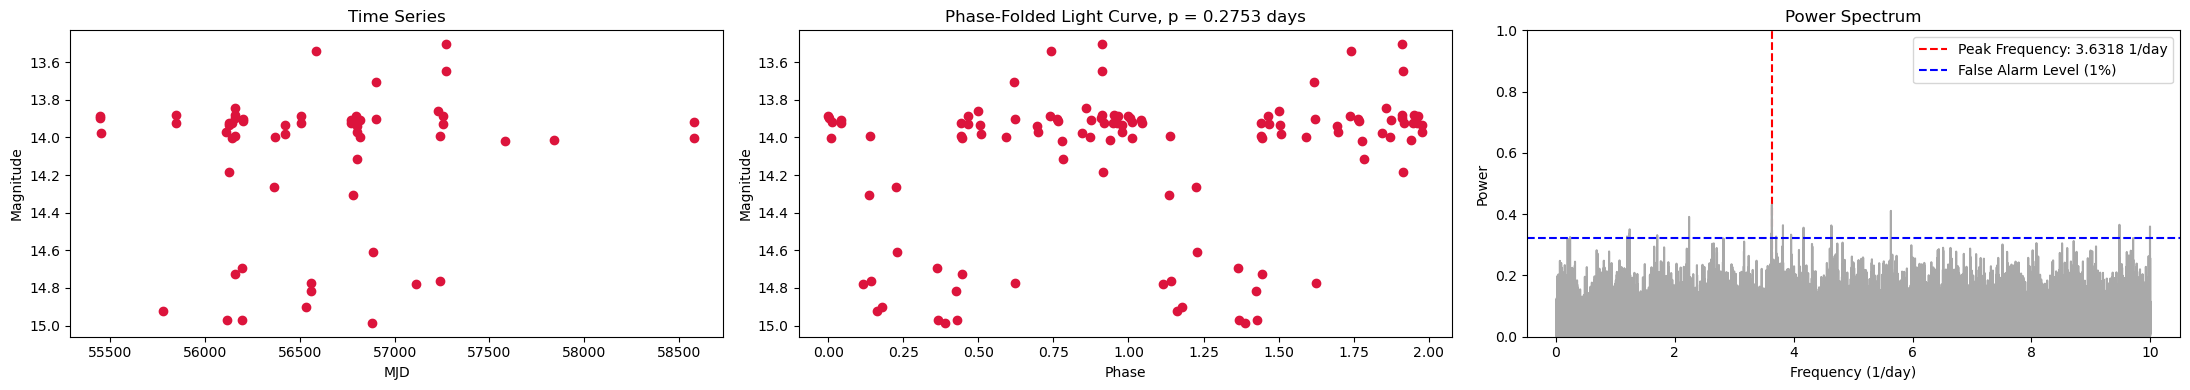

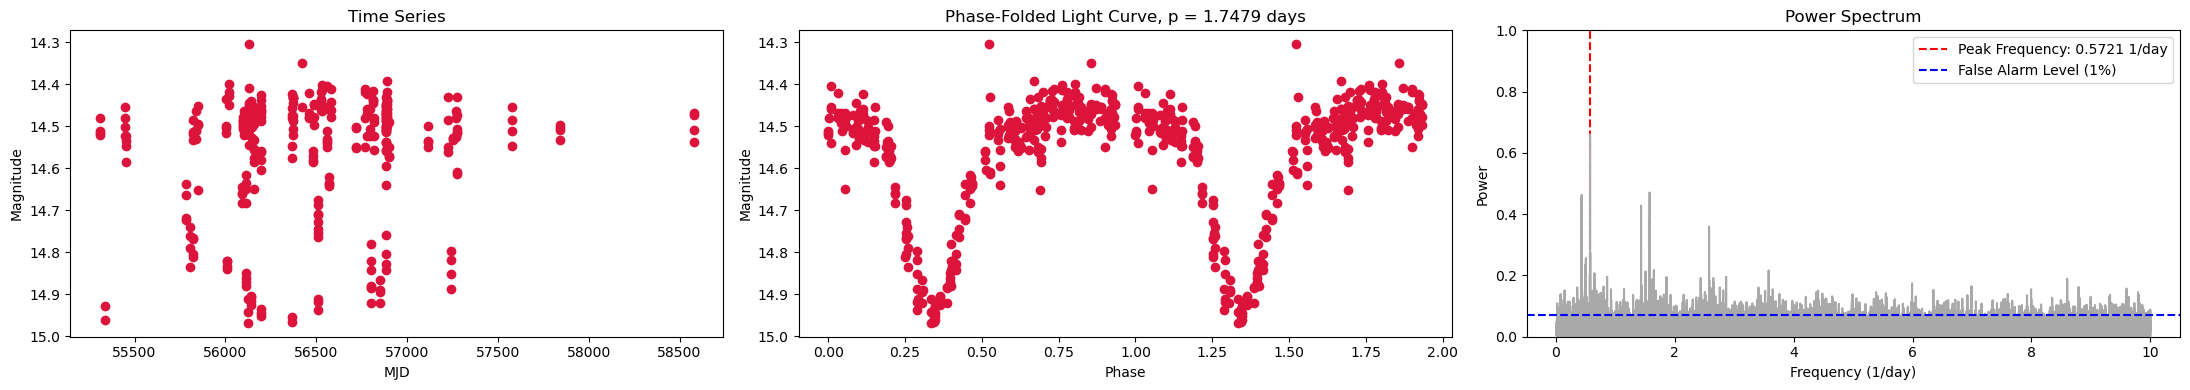

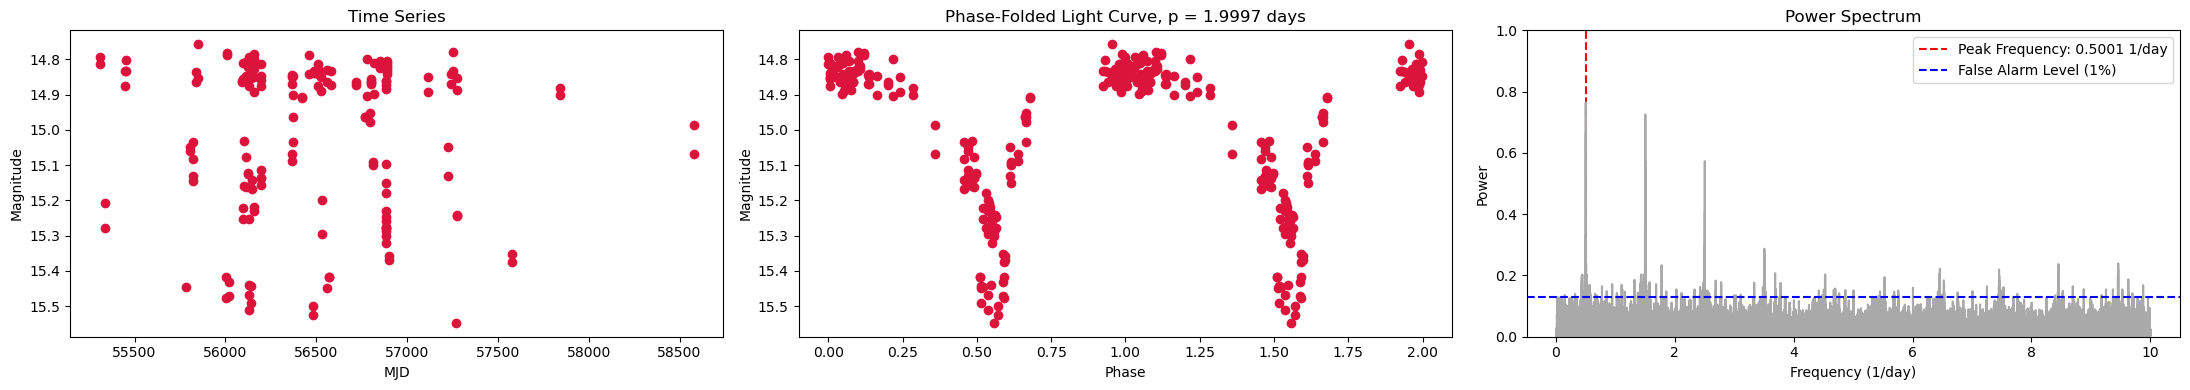

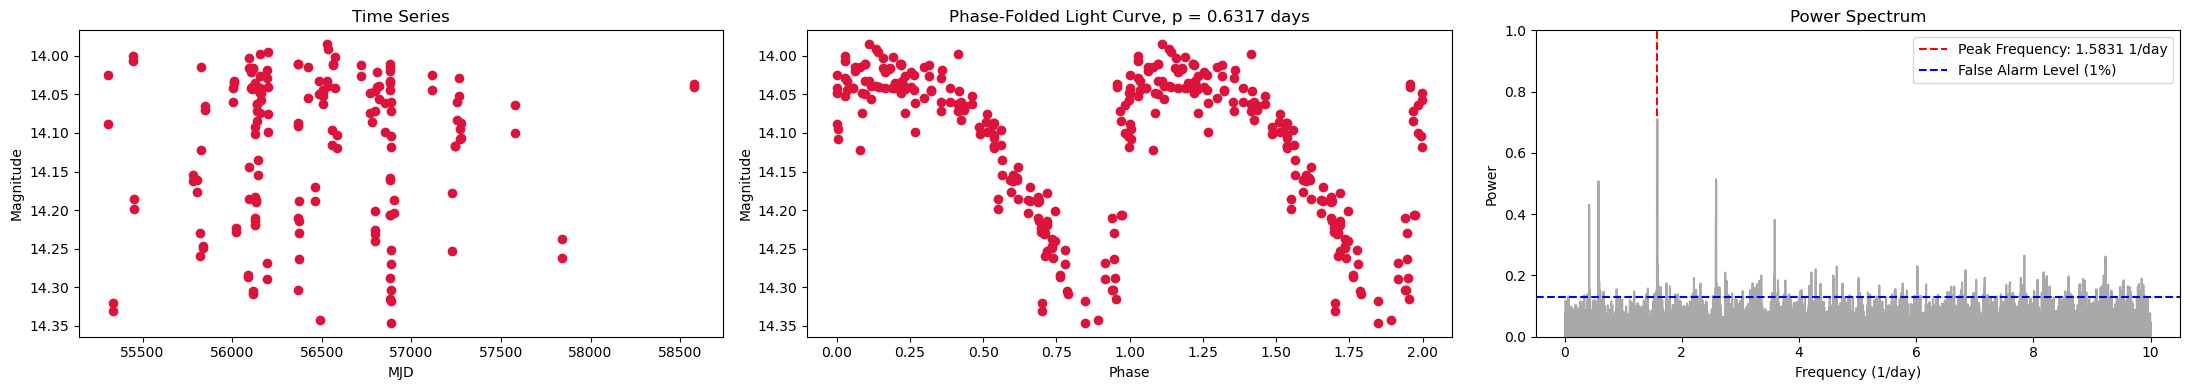

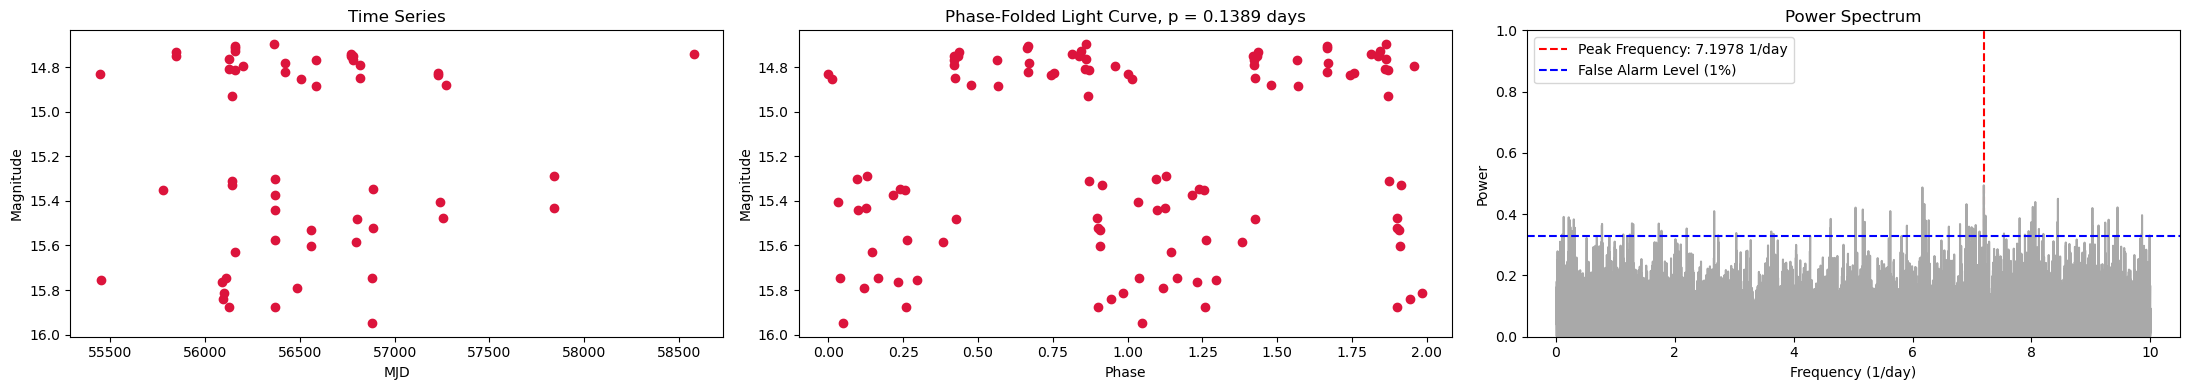

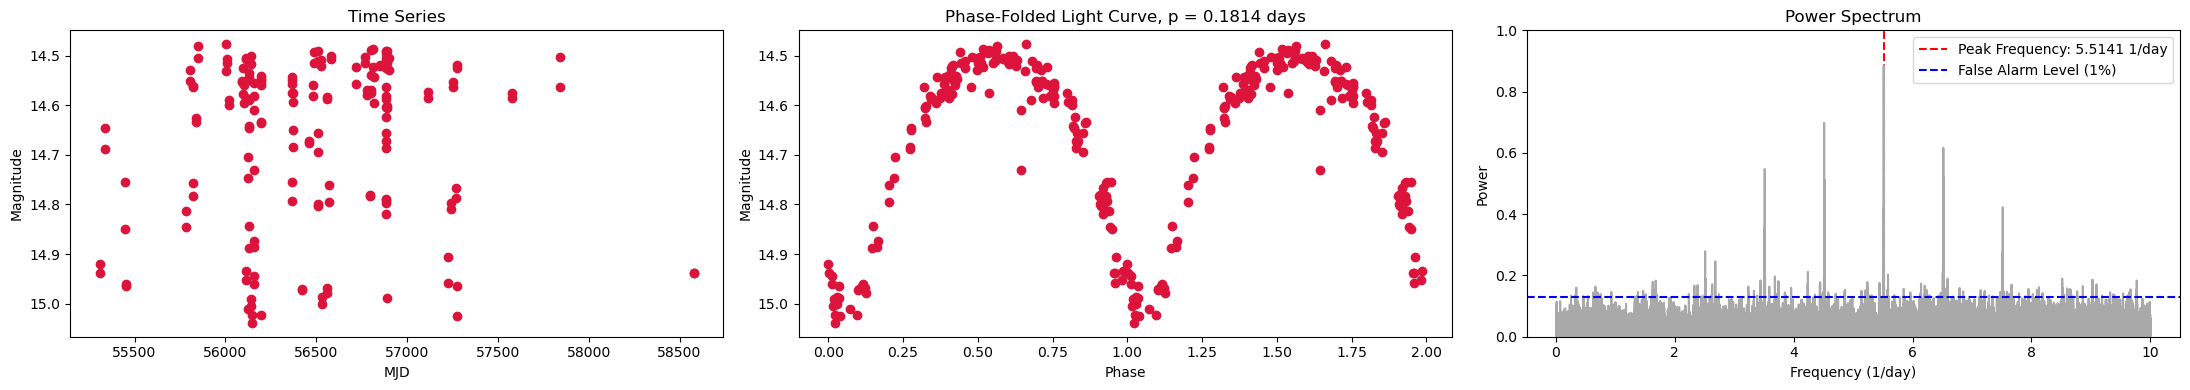

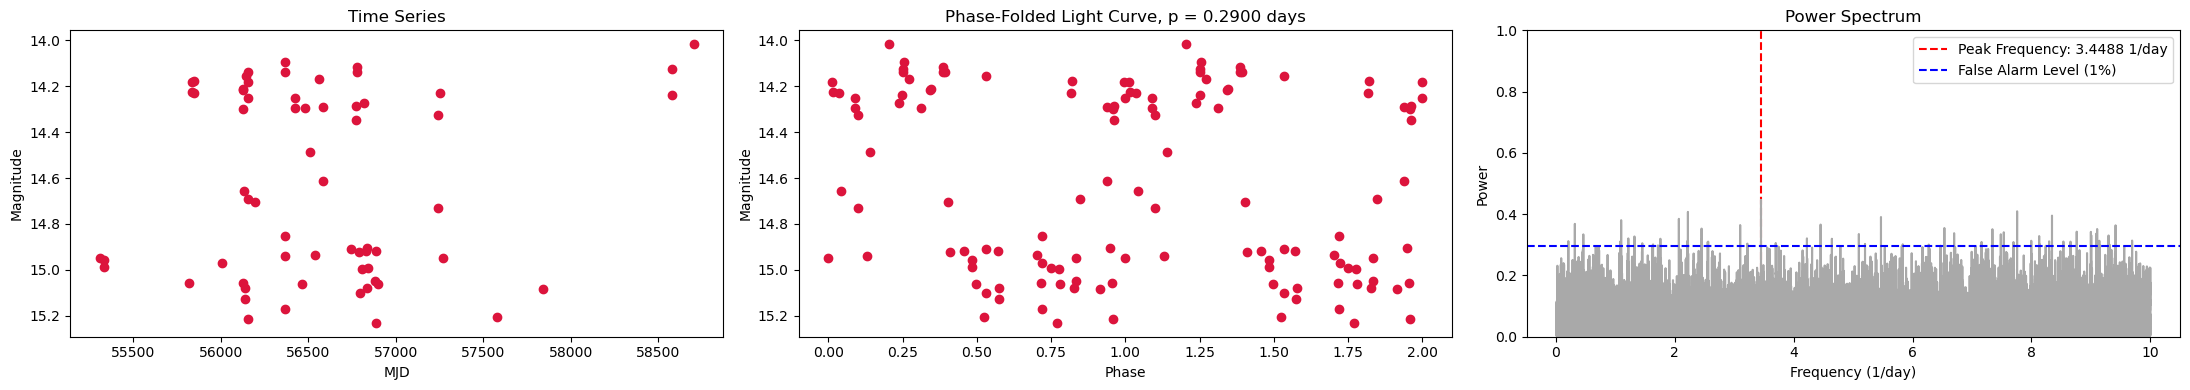

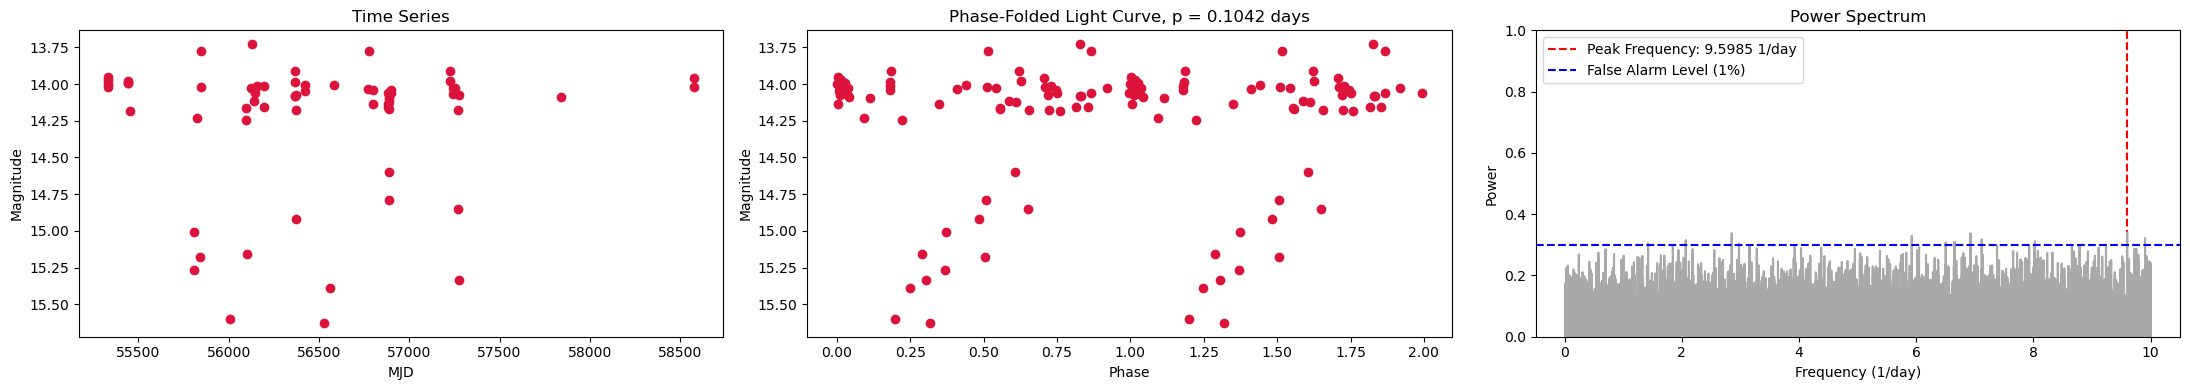

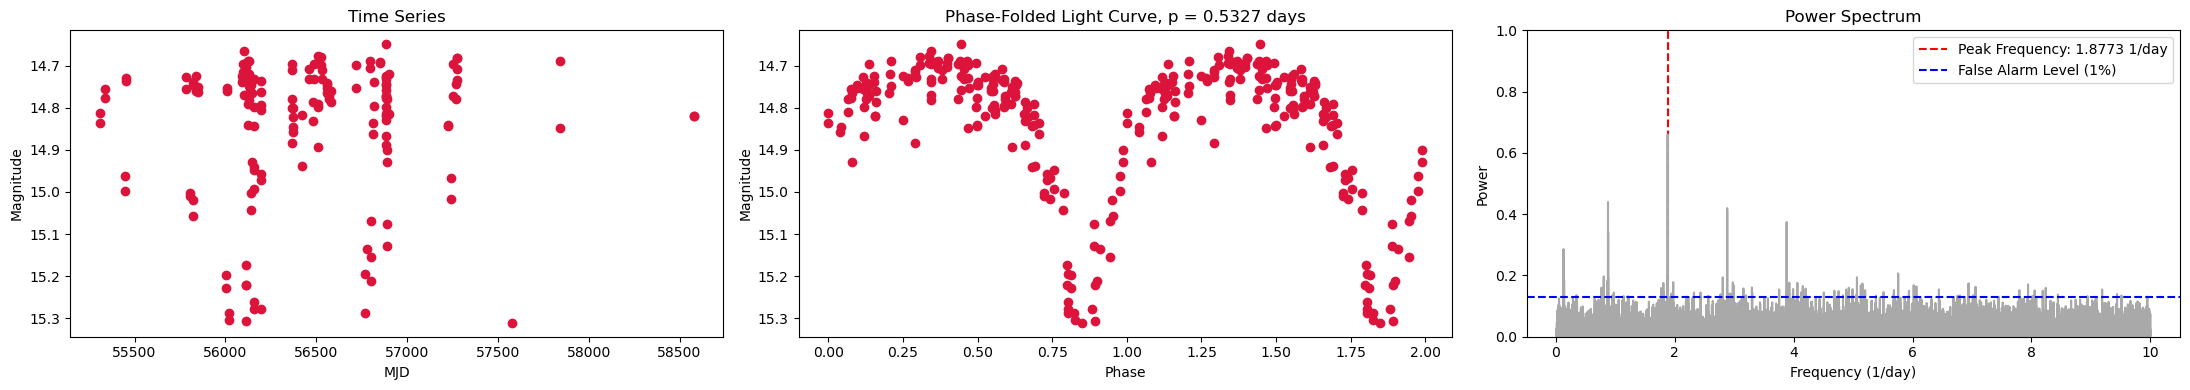

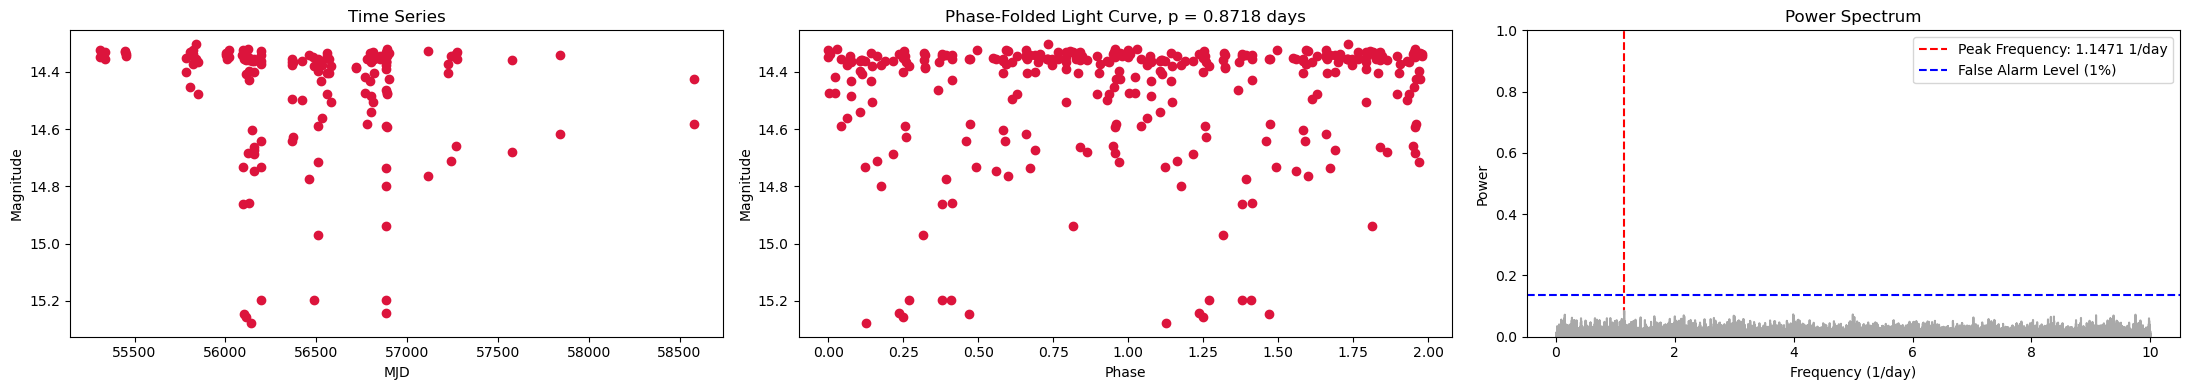

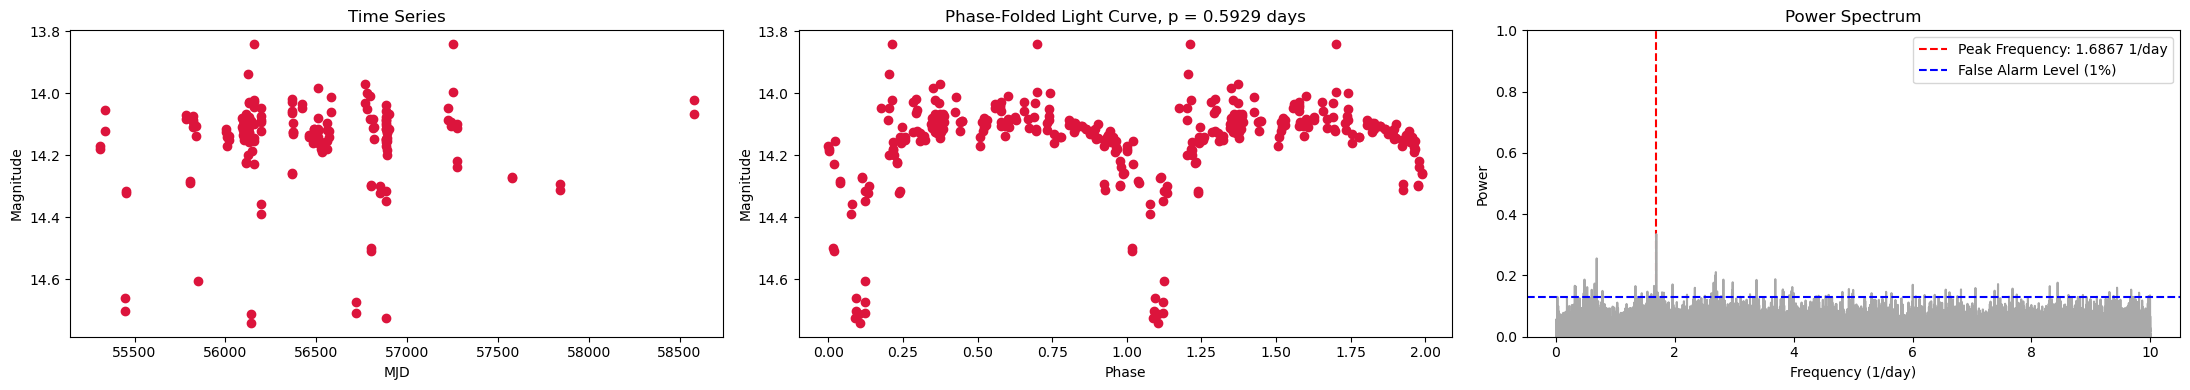

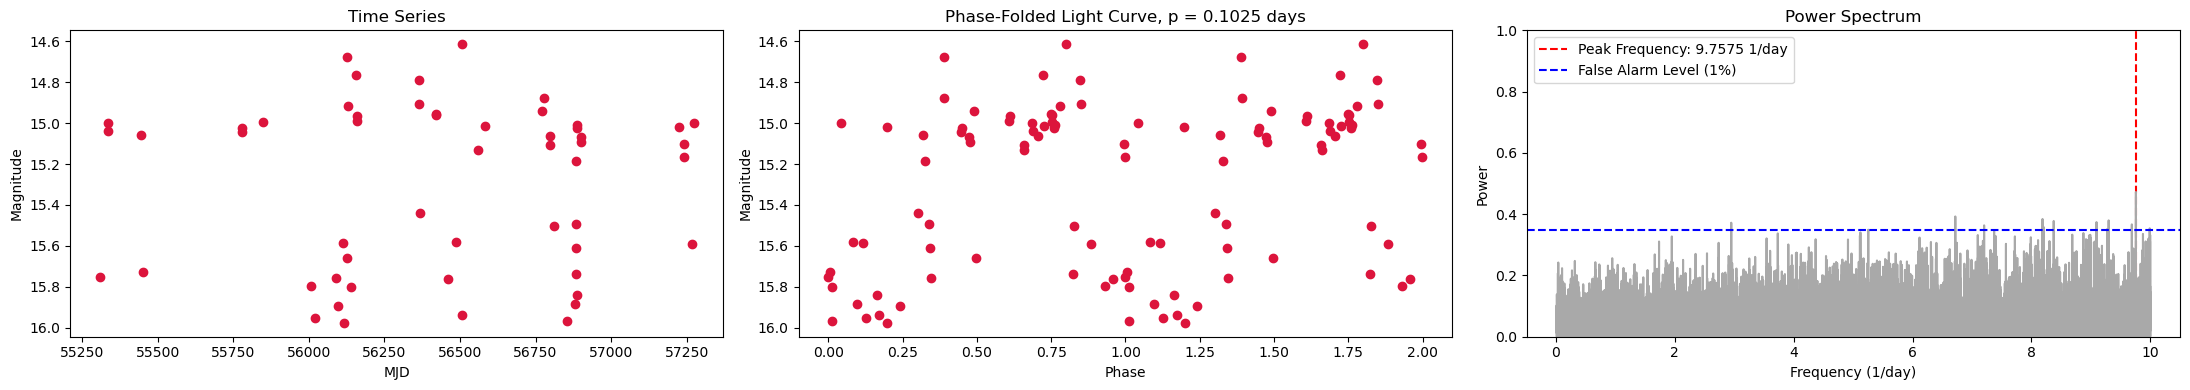

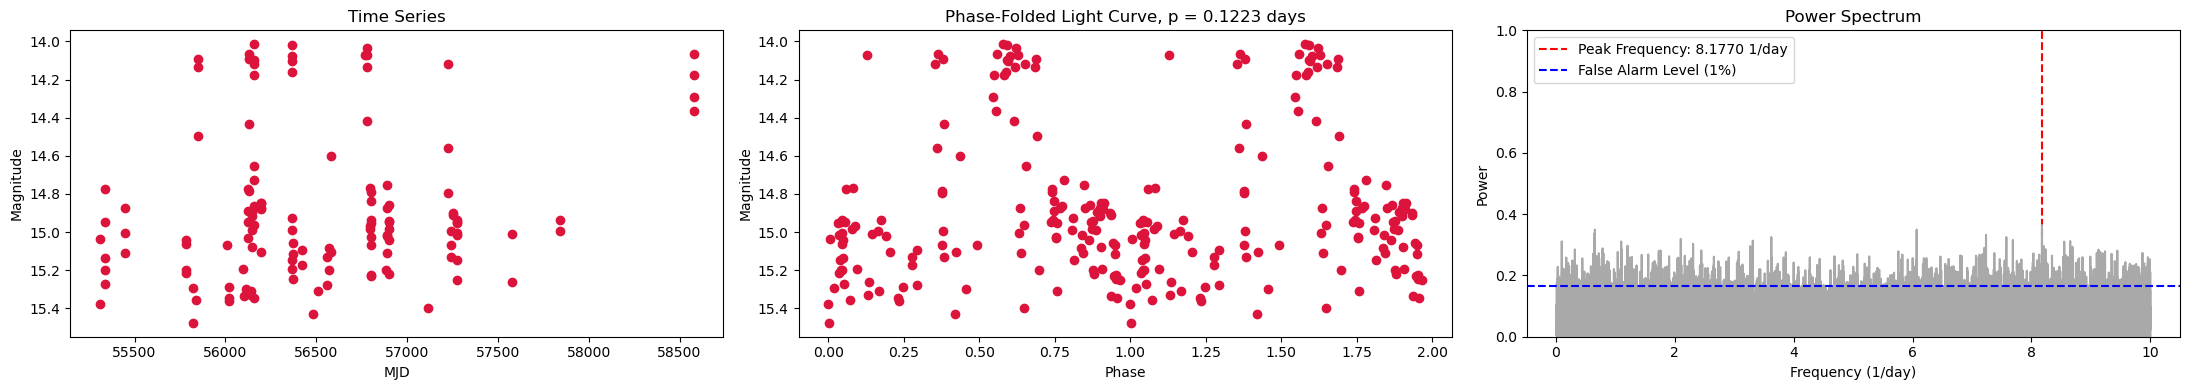

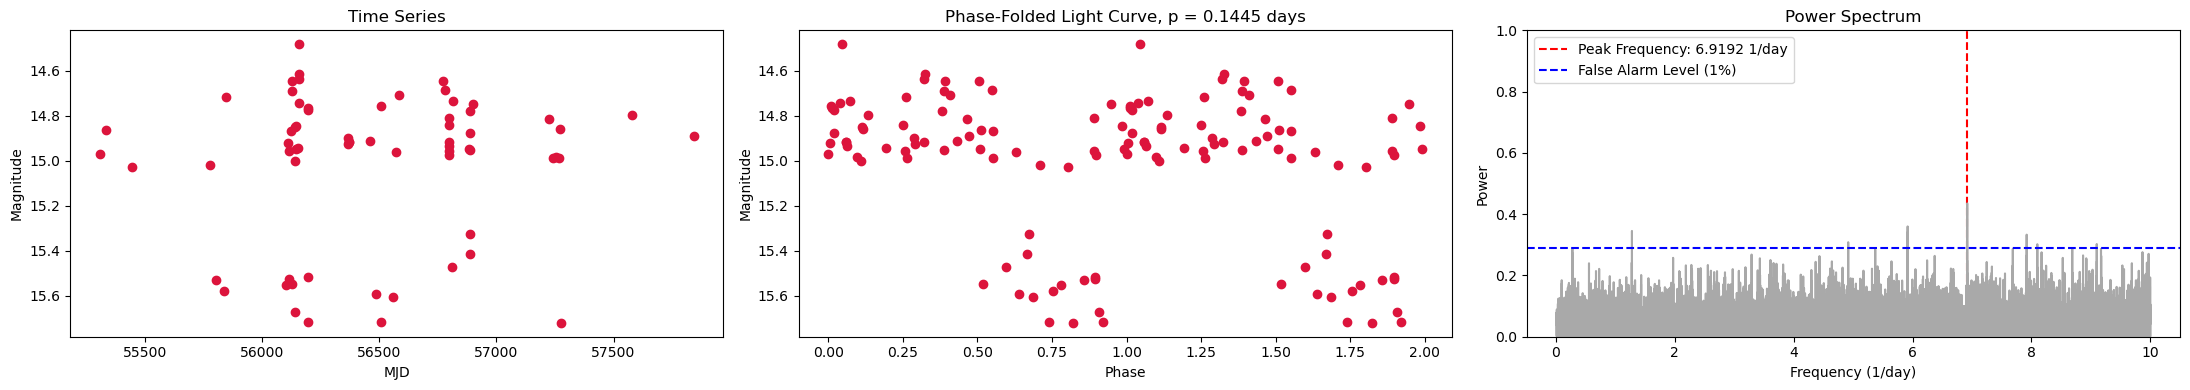

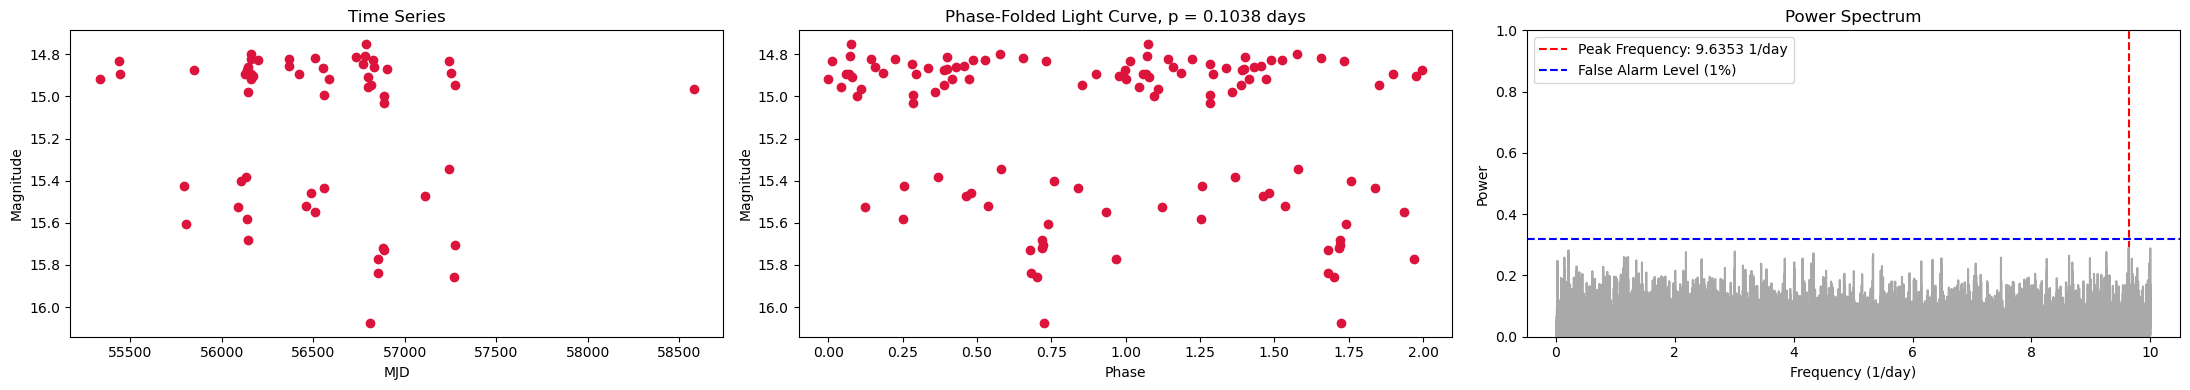

In [10]:
for estrella in range(50):
    mjd = Ks_mjd_b278[estrella]
    mag = Ks_b278[estrella]
    #frequency, power = LombScargle(mjd, mag).autopower(minimum_frequency=1/101, maximum_frequency=10) 
    LS = LombScargle(mjd, mag)
    frequency, power = LS.autopower(minimum_frequency=1/101, maximum_frequency=10)
    period = 1/frequency
    power_max=np.argmax(power)
    frequency_max=frequency[power_max]
    period_max=1/frequency_max
    phase = phase_folding(period_max, mjd)
    plt.figure(figsize=(22, 4))
    plt.subplot(1, 3, 1)
    plt.scatter(mjd, mag, c='crimson')
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.title('Time Series')
    plt.gca().invert_yaxis()
    plt.subplot(1, 3, 2)
    plt.scatter(phase, mag, c='crimson')
    plt.scatter(phase+1, mag, c='crimson')
    plt.xlabel('Phase')
    plt.ylabel('Magnitude')
    plt.title(f'Phase-Folded Light Curve, p = {period_max:.4f} days')
    plt.gca().invert_yaxis()  
    plt.subplot(1, 3, 3)
    plt.plot(frequency, power, color='darkgray')
    plt.axvline(frequency_max, color='red', linestyle='--', label=f'Peak Frequency: {frequency_max:.4f} 1/day', zorder=-10)
    plt.axhline(LS.false_alarm_level(0.01), color='blue', linestyle='--', label='False Alarm Level (1%)')
    plt.legend()
    plt.ylim(0,1)
    plt.xlabel('Frequency (1/day)')
    plt.ylabel('Power')
    plt.title('Power Spectrum')
    plt.tight_layout()
    plt.show()
    plt.close()


Calculando Mínima Entropía para la estrella índice: 2


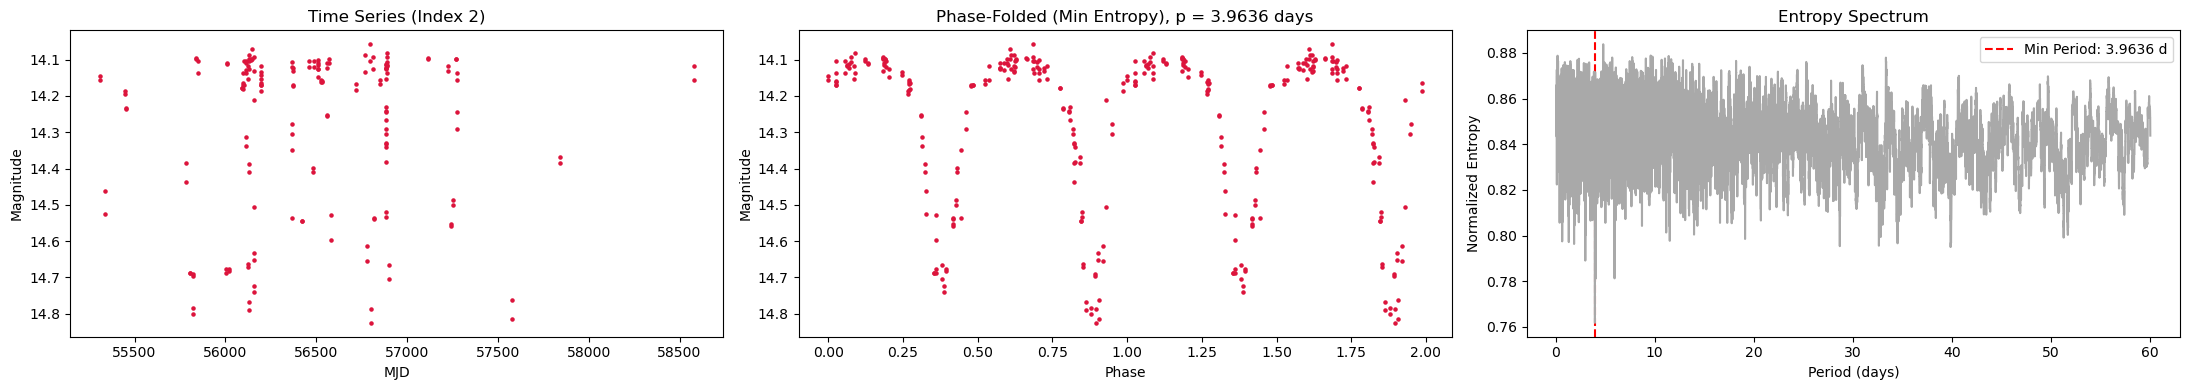

Calculando Mínima Entropía para la estrella índice: 6


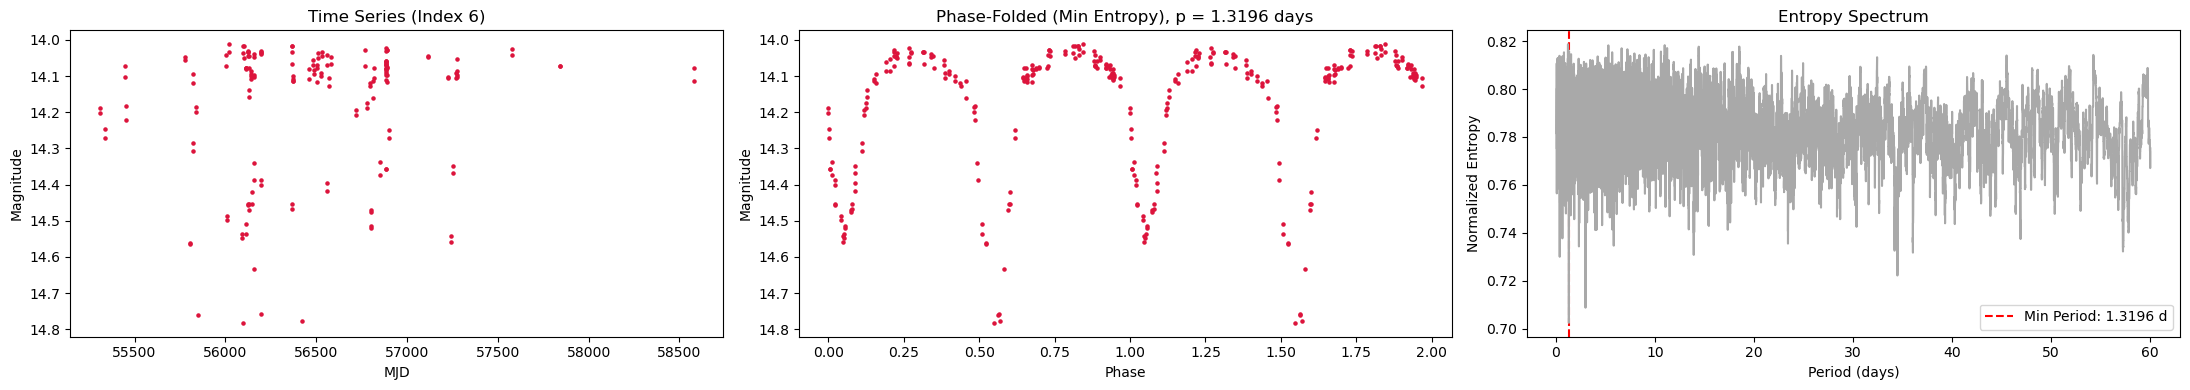

Calculando Mínima Entropía para la estrella índice: 7


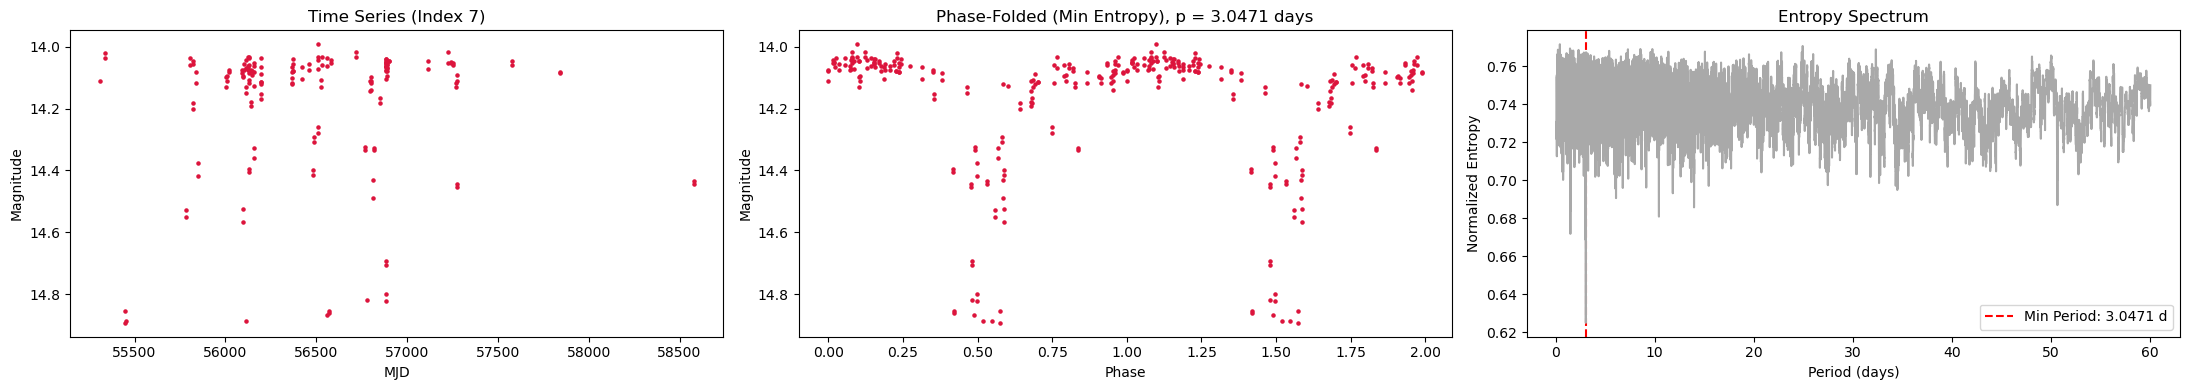

Calculando Mínima Entropía para la estrella índice: 8


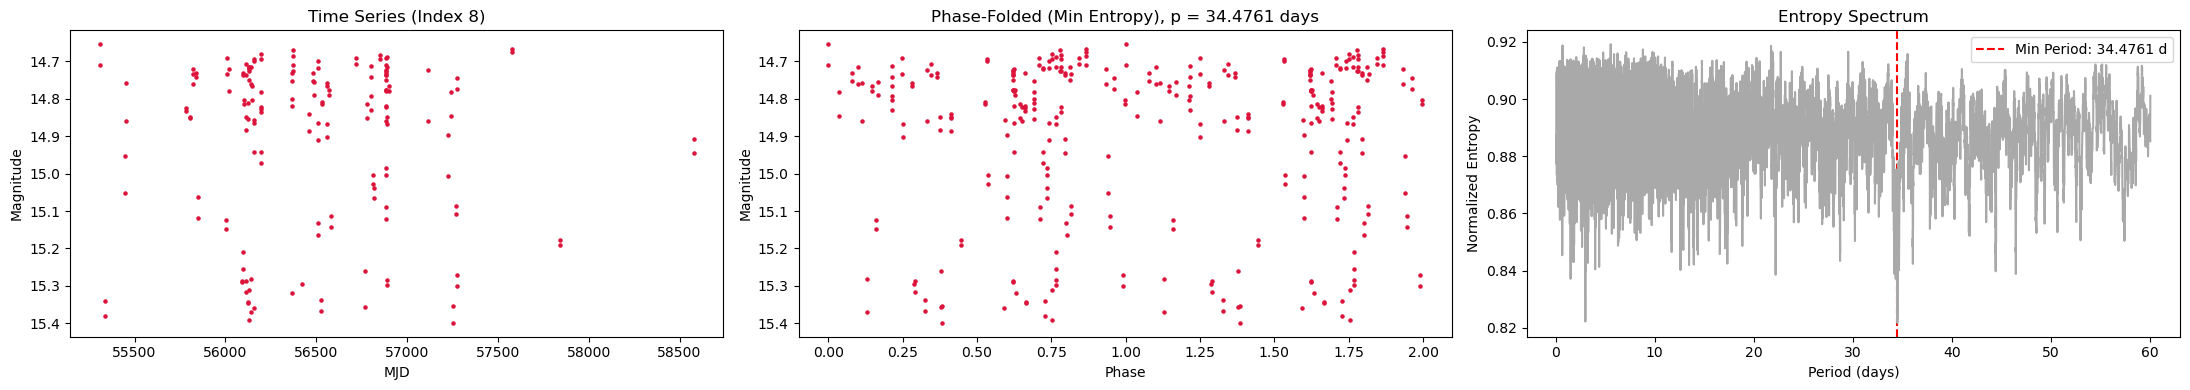

Calculando Mínima Entropía para la estrella índice: 9


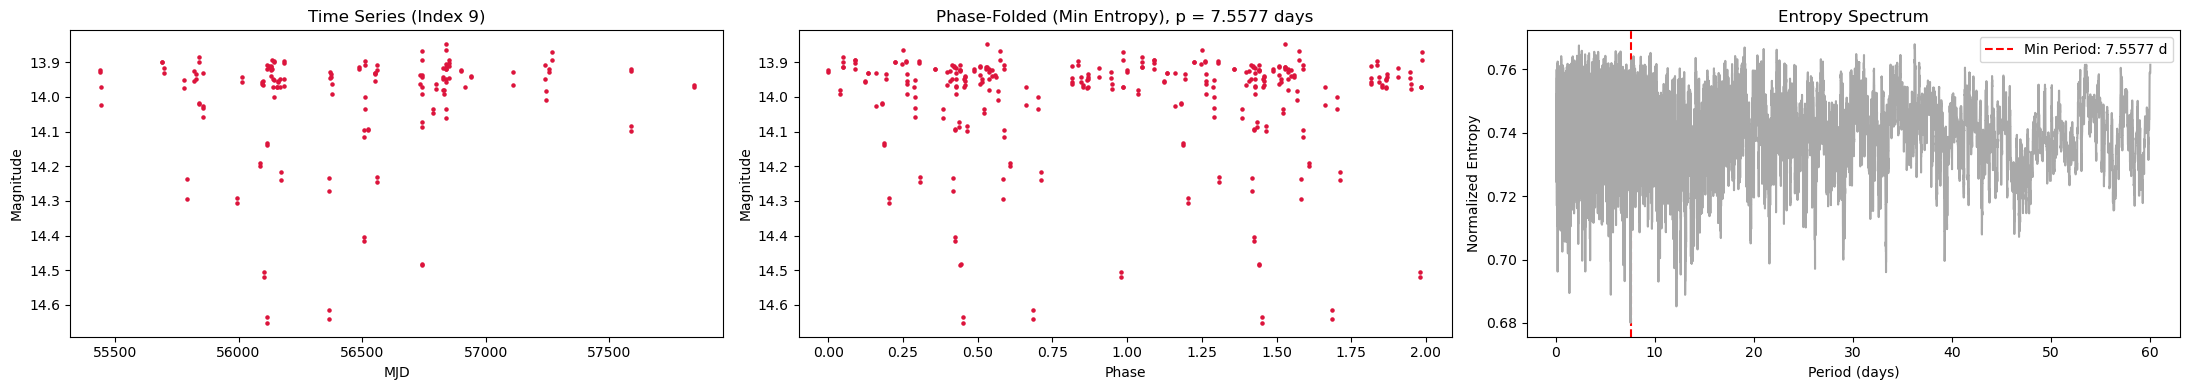

Calculando Mínima Entropía para la estrella índice: 14


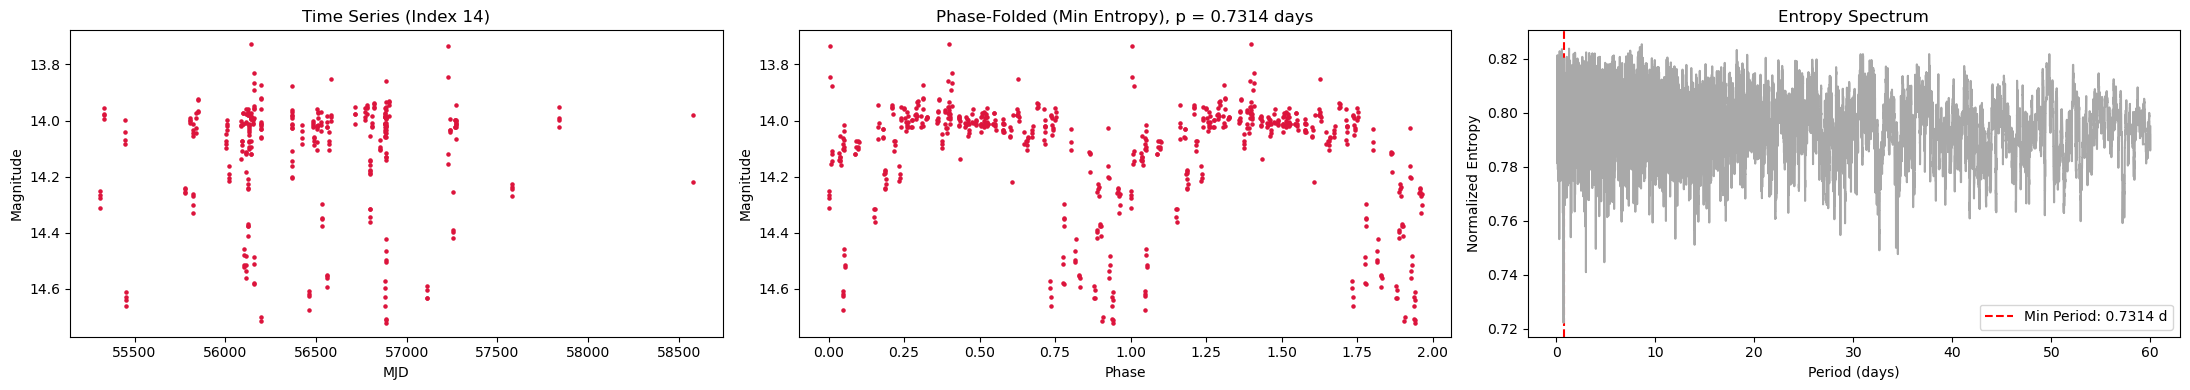

Calculando Mínima Entropía para la estrella índice: 16


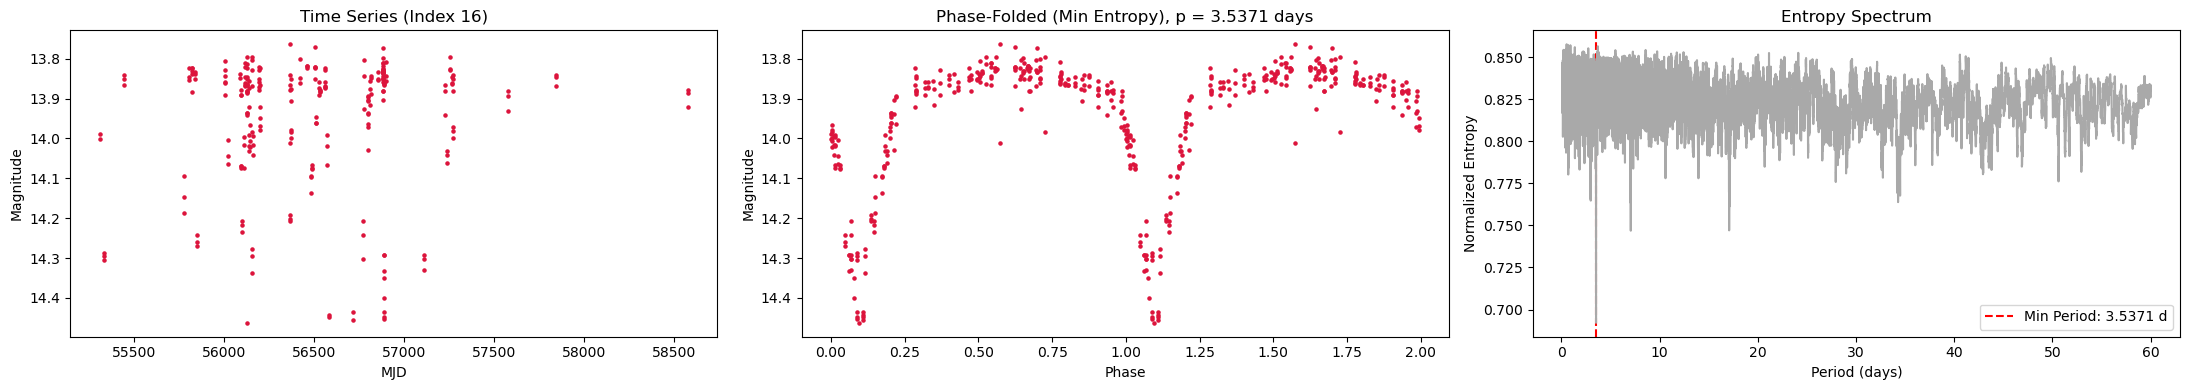

Calculando Mínima Entropía para la estrella índice: 17


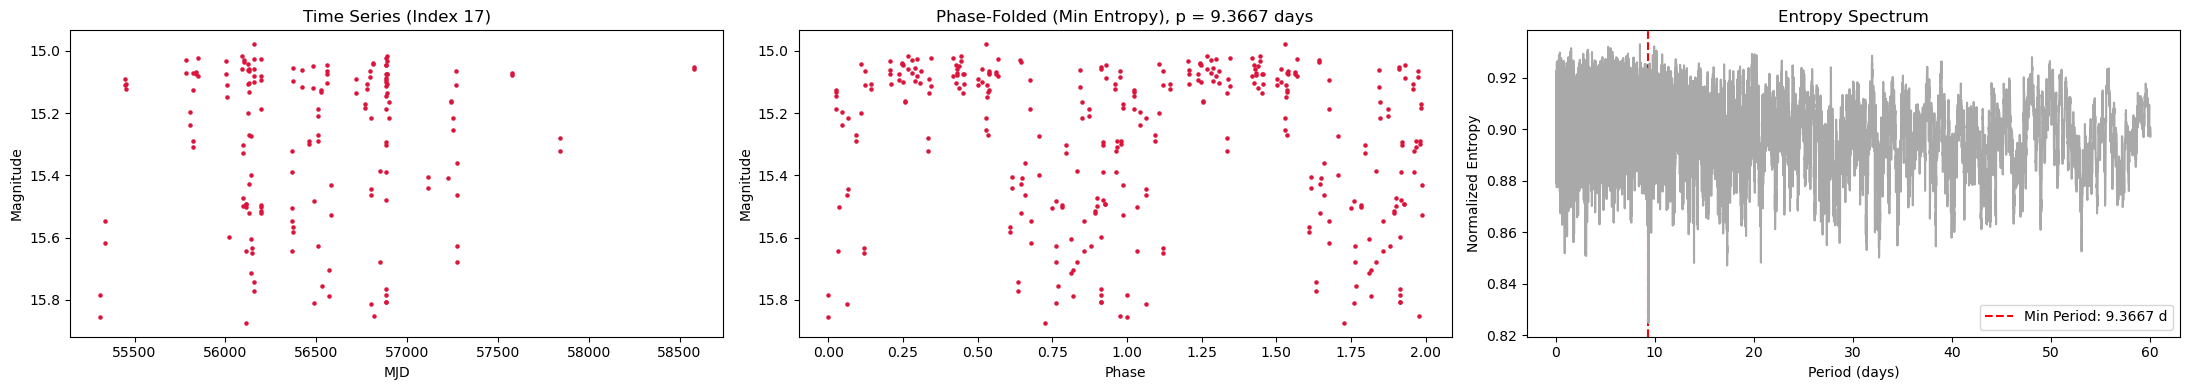

Calculando Mínima Entropía para la estrella índice: 22


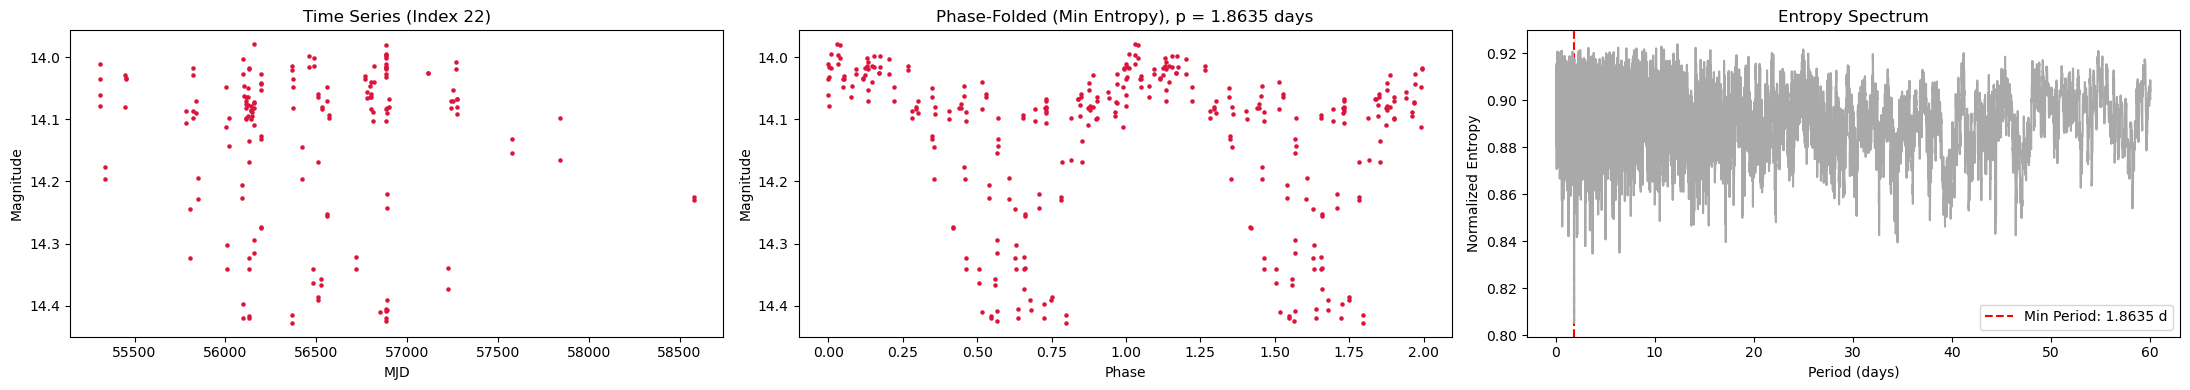

Calculando Mínima Entropía para la estrella índice: 23


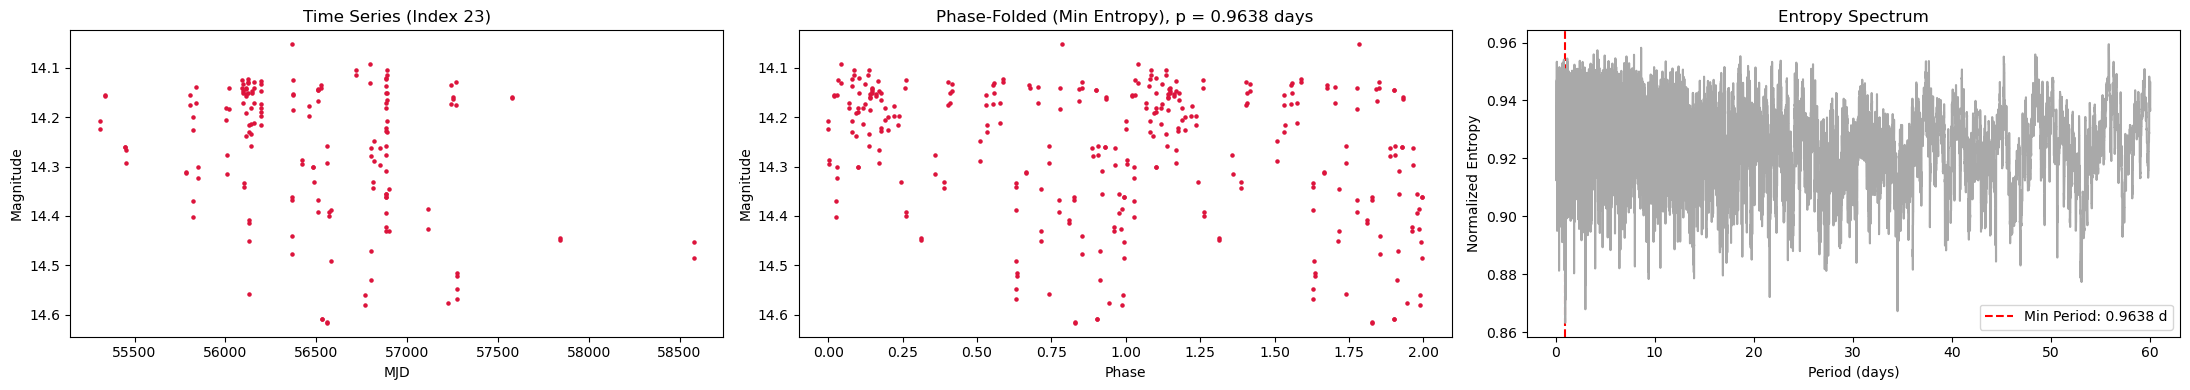

In [ ]:
#Minima Entropía

def calculate_entropy(phi_norm, mag_norm, m):
    hist, _, _ = np.histogram2d(phi_norm, mag_norm, bins=(m, m))
    count = hist.flatten()
    mu = (count / len(phi_norm)) + 1e-10 
    
    # Calculate Shannon Entropy (S = -sum(mu * log(mu)))
    s = -np.sum(mu * np.log(mu))
    
    # Normalize by the maximum possible entropy (log(m*m))
    return s / np.log(m * m)

def periodogram_entropy(mjd, mag_norm, periods, m):
    entropies = np.empty(len(periods), dtype=float)
    
    for i, p in enumerate(periods):
        phi = phase_folding(p, mjd)
        phi_norm = _safe_norm(phi)
        entropies[i] = calculate_entropy(phi_norm, mag_norm, m)
        
    return entropies

periodo_prueba = np.linspace(0.1, 60, 50000)
frecuencias = 1.0 / periodo_prueba
atol_val = 0.02 
es_alias_entero = np.any([np.isclose(frecuencias, i, atol=atol_val) for i in range(1, 10)], axis=0)
es_alias_fraccional = np.any([np.isclose(frecuencias, 1/frac, atol=atol_val) for frac in [0.5, 2.0]], axis=0)
mascara_segura = ~(es_alias_entero | es_alias_fraccional)
periodo_prueba_limpio = periodo_prueba[mascara_segura]


estrellas_seleccionadas = [2, 6, 7, 8, 9, 14, 16, 17, 22, 23]


m_bins = 5 

for estrella in estrellas_seleccionadas:
    print(f"Calculando Mínima Entropía para la estrella índice: {estrella}")
    
    mjd = Ks_mjd_b278[estrella]
    mag = Ks_b278[estrella]

    m_bins = 5
    
    mag_norm = _safe_norm(mag)
    entropies = periodogram_entropy(mjd, mag_norm, periodo_prueba_limpio, m=m_bins)

    # Encontrar el VALLE (mínimo) de entropía
    indice_minimo = np.argmin(entropies)
    period_min_entropy = periodo_prueba_limpio[indice_minimo]
    entropy_min_val = entropies[indice_minimo]
    
    phase = phase_folding(period_min_entropy, mjd)

    plt.figure(figsize=(22, 4))
    plt.subplot(1, 3, 1)
    plt.scatter(mjd, mag, c='crimson', s=5) 
    plt.xlabel('MJD')
    plt.ylabel('Magnitude')
    plt.title(f'Time Series (Index {estrella})')
    plt.gca().invert_yaxis()
    
    # Panel 2: Curva de luz plegada
    plt.subplot(1, 3, 2)
    plt.scatter(phase, mag, c='crimson', s=5)
    plt.scatter(phase + 1, mag, c='crimson', s=5)
    plt.xlabel('Phase')
    plt.ylabel('Magnitude')
    plt.title(f'Phase-Folded (Min Entropy), p = {period_min_entropy:.4f} days')
    plt.gca().invert_yaxis()  
    
    # Panel 3: Espectro de Entropía
    plt.subplot(1, 3, 3)
    plt.plot(periodo_prueba_limpio, entropies, color='darkgray')
    plt.axvline(period_min_entropy, color='red', linestyle='--', 
                label=f'Min Period: {period_min_entropy:.4f} d', zorder=-10)
    plt.legend()
    # plt.ylim(0, 1) # Opcional: descomentar si quieres forzar la escala de entropía de 0 a 1
    plt.xlabel('Period (days)')
    plt.ylabel('Normalized Entropy')
    plt.title('Entropy Spectrum')
    
    plt.tight_layout()
    plt.show()
    plt.close()